DATA 994 Capstone Project — Siddartha Bandi
Comparative Analysis of ML and DL Models for Multi-Level Anomaly Detection

NOTEBOOK 1: Kaggle API Setup + Exploratory Data Analysis (EDA)

HOW TO USE IN GOOGLE COLAB:

1. Open Google Colab → New Notebook
2. Copy each CELL block into a separate Colab cell
3. Run Cell 1 first (installs libraries)
4. Run Cell 2 — it will pop up a file picker
    - Upload your kaggle.json from your Downloads folder
5. Run remaining cells in order
6. All 8 plots saved to /content/ automatically

# **Quarter 1: EDA & Kaggle API Integration**

##**Install Libraries**


In [1]:
# Run this cell first. If Colab asks to restart runtime, click "Restart"
# then continue from Cell 2 (do NOT re-run Cell 1 after restart)

!pip install kaggle --quiet
!pip install imbalanced-learn --quiet   # needed for Notebook 2 (SMOTE)

print(" All libraries installed.")

 All libraries installed.


## **Upload kaggle.json and Download Dataset**

In [2]:
# When the file picker appears:
#   Go to your Downloads folder
#   Select the kaggle.json file you downloaded from kaggle.com/settings
# The dataset (~144MB) will download automatically after upload

import os
from google.colab import files

# Step 1: Upload kaggle.json
print(" A file picker will appear below.")
print("   Select your kaggle.json from your Downloads folder.\n")

uploaded = files.upload()

# Verify the right file was uploaded
if "kaggle.json" not in uploaded:
    print(" Wrong file uploaded. Please upload 'kaggle.json' and re-run this cell.")
else:
    print(" kaggle.json uploaded successfully.\n")

    # Step 2: Place kaggle.json in the correct directory
    kaggle_dir = os.path.expanduser("~/.kaggle")
    os.makedirs(kaggle_dir, exist_ok=True)

    # Move the file to ~/.kaggle/kaggle.json
    os.rename("kaggle.json", os.path.join(kaggle_dir, "kaggle.json"))

    # Set correct permissions (required by Kaggle API)
    os.chmod(os.path.join(kaggle_dir, "kaggle.json"), 0o600)

    print(" kaggle.json placed in ~/.kaggle/ with correct permissions.\n")

    # Step 3: Verify credentials
    import json
    with open(os.path.join(kaggle_dir, "kaggle.json"), "r") as f:
        creds = json.load(f)
    print(f" Credentials verified for user: {creds['username']}\n")

    # Step 4: Download the dataset
    print(" Downloading Credit Card Fraud Detection dataset...")
    print("   Source : kaggle.com/datasets/mlg-ulb/creditcardfraud")
    print("   Size   : ~144 MB (may take 30–60 seconds)\n")

    os.system("kaggle datasets download -d mlg-ulb/creditcardfraud -p /content/ --unzip")

    # Step 5: Verify download
    csv_path = "/content/creditcard.csv"
    if os.path.exists(csv_path):
        size_mb = os.path.getsize(csv_path) / 1e6
        print(f"\n Dataset ready: creditcard.csv ({size_mb:.1f} MB)")
        print("   Proceed to Next Cell")
    else:
        print("\n Download failed. Possible reasons:")
        print("   1. Check your kaggle.json credentials are correct")
        print("   2. Make sure you accepted the dataset rules on Kaggle")
        print(f"      → Visit: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud")
        print("   3. Re-run this cell after fixing the issue")



 A file picker will appear below.
   Select your kaggle.json from your Downloads folder.



Saving kaggle.json to kaggle.json
 kaggle.json uploaded successfully.

 kaggle.json placed in ~/.kaggle/ with correct permissions.

 Credentials verified for user: siddarthabandi05

   Source : kaggle.com/datasets/mlg-ulb/creditcardfraud
   Size   : ~144 MB (may take 30–60 seconds)


 Dataset ready: creditcard.csv (150.8 MB)
   Proceed to Next Cell


## **Import Libraries & Configure Settings**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams.update({
    'figure.dpi'        : 120,
    'font.family'       : 'serif',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#FAFAFA',
})

# Project color palette
FRAUD_COLOR   = '#E63946'   # Red   — fraudulent transactions
LEGIT_COLOR   = '#457B9D'   # Blue  — legitimate transactions
NEUTRAL_COLOR = '#2D6A4F'   # Green — neutral totals

print("  DATA 994 Capstone  |  EDA Notebook  |  Siddartha Bandi")
print(f"\n Libraries ready")
print(f"   NumPy   : {np.__version__}")
print(f"   Pandas  : {pd.__version__}")
print(f"   Seaborn : {sns.__version__}")

  DATA 994 Capstone  |  EDA Notebook  |  Siddartha Bandi

 Libraries ready
   NumPy   : 2.0.2
   Pandas  : 2.2.2
   Seaborn : 0.13.2


## **Load Dataset & Basic Overview**

In [4]:
df = pd.read_csv("/content/creditcard.csv")


print("DATASET OVERVIEW")
print(f"\n  Shape         : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print(f"  File size     : {os.path.getsize('/content/creditcard.csv')/1e6:.1f} MB")
print(f"  Memory usage  : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"  Duplicates    : {df.duplicated().sum()}")
print(f"\n  Columns :\n  {list(df.columns)}")
print(f"\n  Data Types:\n{df.dtypes.value_counts().to_string()}")

print("\n First 5 Rows")
print(df.head())

print("\n Statistical Summary (Time, Amount, Class)")
print(df[['Time', 'Amount', 'Class']].describe().round(4))

DATASET OVERVIEW

  Shape         : 284,807 rows  ×  31 columns
  File size     : 150.8 MB
  Memory usage  : 70.6 MB
  Missing values: 0
  Duplicates    : 1081

  Columns :
  ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

  Data Types:
float64    30
int64       1

 First 5 Rows
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V2

## **Class Distribution Analysis**


CLASS DISTRIBUTION

  Legitimate (0) : 284,315  (99.8273%)
  Fraudulent (1) :     492  (0.1727%)
  Total          : 284,807

 Imbalance Ratio : 577:1  (legitimate : fraud)
  SMOTE rebalancing required before supervised model training


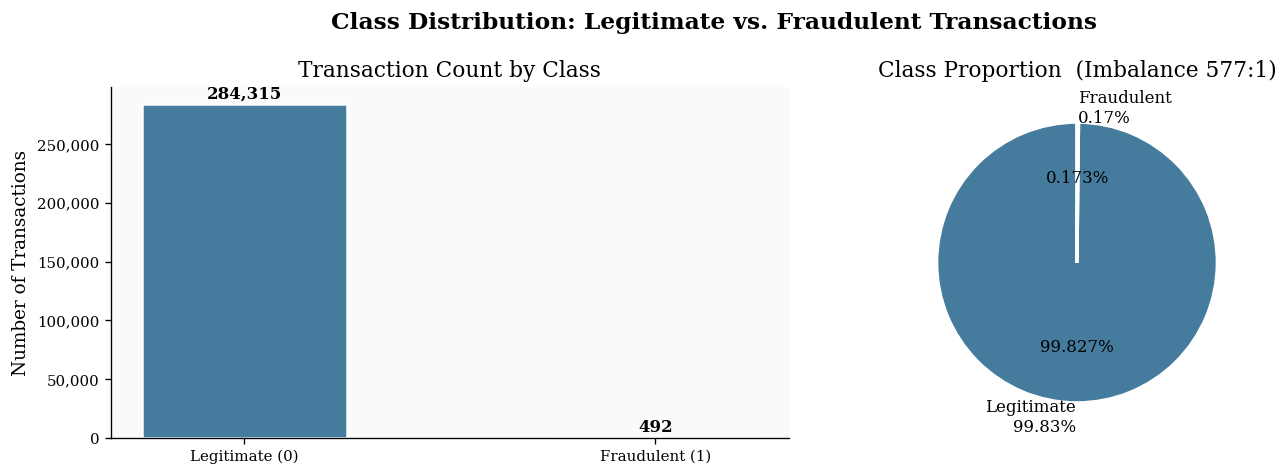

 Saved: plot_01_class_distribution.png


In [5]:
fraud_count = int(df['Class'].sum())
legit_count = len(df) - fraud_count
total       = len(df)
fraud_pct   = fraud_count / total * 100
legit_pct   = legit_count / total * 100
ratio       = legit_count // fraud_count

print("CLASS DISTRIBUTION")
print(f"\n  Legitimate (0) : {legit_count:>7,}  ({legit_pct:.4f}%)")
print(f"  Fraudulent (1) : {fraud_count:>7,}  ({fraud_pct:.4f}%)")
print(f"  Total          : {total:>7,}")
print(f"\n Imbalance Ratio : {ratio}:1  (legitimate : fraud)")
print(f"  SMOTE rebalancing required before supervised model training")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Class Distribution: Legitimate vs. Fraudulent Transactions",
             fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(
    ['Legitimate (0)', 'Fraudulent (1)'],
    [legit_count, fraud_count],
    color=[LEGIT_COLOR, FRAUD_COLOR],
    edgecolor='white', linewidth=1.5, width=0.5
)
for bar, count in zip(bars, [legit_count, fraud_count]):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1500,
        f'{count:,}', ha='center', va='bottom',
        fontweight='bold', fontsize=10
    )
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Number of Transactions')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Pie chart
axes[1].pie(
    [legit_pct, fraud_pct],
    labels=[f'Legitimate\n{legit_pct:.2f}%', f'Fraudulent\n{fraud_pct:.2f}%'],
    colors=[LEGIT_COLOR, FRAUD_COLOR],
    startangle=90, autopct='%1.3f%%',
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10}
)
axes[1].set_title(f'Class Proportion  (Imbalance {ratio}:1)')

plt.tight_layout()
plt.savefig('/content/plot_01_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Saved: plot_01_class_distribution.png")


## **Transaction Amount Analysis**

TRANSACTION AMOUNT  —  FRAUD vs. LEGITIMATE

  Metric             Legitimate    Fraudulent
  ──────────────────────────────────────────
  Mean            €      88.29 €     122.21
  Median          €      22.00 €       9.25
  Std Dev         €     250.10 €     256.42
  Min             €       0.00 €       0.00
  Max             €   25691.16 €    2125.87

 Mann-Whitney U Test (non-parametric)
     U statistic : 61833399
     p-value     : 8.58e-06
     Result      :  Significant difference at α=0.05


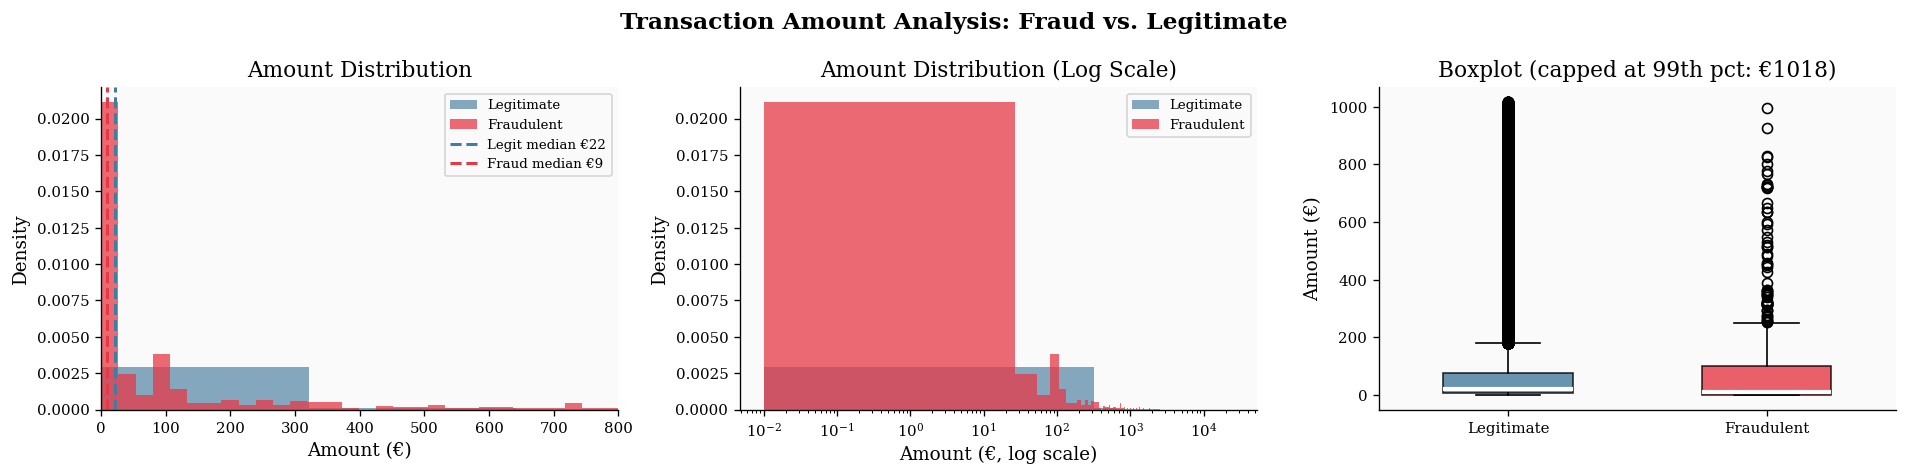

 Saved: plot_02_amount_analysis.png


In [6]:
fraud_amounts = df[df['Class'] == 1]['Amount']
legit_amounts = df[df['Class'] == 0]['Amount']

print("TRANSACTION AMOUNT  —  FRAUD vs. LEGITIMATE")
print(f"\n  {'Metric':<15} {'Legitimate':>13} {'Fraudulent':>13}")
print("  " + "─" * 42)
for func, name in [
    (np.mean,   'Mean'),
    (np.median, 'Median'),
    (np.std,    'Std Dev'),
    (np.min,    'Min'),
    (np.max,    'Max')
]:
    print(f"  {name:<15} €{func(legit_amounts):>11.2f} €{func(fraud_amounts):>11.2f}")

# Mann-Whitney U test (non-parametric, appropriate for non-normal distributions)
u_stat, p_val = stats.mannwhitneyu(
    fraud_amounts, legit_amounts, alternative='two-sided'
)
print(f"\n Mann-Whitney U Test (non-parametric)")
print(f"     U statistic : {u_stat:.0f}")
print(f"     p-value     : {p_val:.2e}")
print(f"     Result      : {' Significant difference' if p_val < 0.05 else ' No significant difference'} at α=0.05")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Transaction Amount Analysis: Fraud vs. Legitimate",
             fontsize=14, fontweight='bold')

# Density histogram
axes[0].hist(legit_amounts, bins=80, color=LEGIT_COLOR,
             alpha=0.65, label='Legitimate', density=True)
axes[0].hist(fraud_amounts, bins=80, color=FRAUD_COLOR,
             alpha=0.75, label='Fraudulent', density=True)
axes[0].axvline(legit_amounts.median(), color=LEGIT_COLOR, linestyle='--',
                linewidth=1.8, label=f'Legit median €{legit_amounts.median():.0f}')
axes[0].axvline(fraud_amounts.median(), color=FRAUD_COLOR, linestyle='--',
                linewidth=1.8, label=f'Fraud median €{fraud_amounts.median():.0f}')
axes[0].set_xlim(0, 800)
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount Distribution')
axes[0].legend(fontsize=8)

# Log scale
axes[1].hist(legit_amounts + 0.01, bins=80, color=LEGIT_COLOR,
             alpha=0.65, label='Legitimate', density=True)
axes[1].hist(fraud_amounts + 0.01, bins=80, color=FRAUD_COLOR,
             alpha=0.75, label='Fraudulent', density=True)
axes[1].set_xscale('log')
axes[1].set_xlabel('Amount (€, log scale)')
axes[1].set_ylabel('Density')
axes[1].set_title('Amount Distribution (Log Scale)')
axes[1].legend(fontsize=8)

# Boxplot (99th percentile cap)
cap = df['Amount'].quantile(0.99)
bp = axes[2].boxplot(
    [legit_amounts[legit_amounts < cap],
     fraud_amounts[fraud_amounts < cap]],
    labels=['Legitimate', 'Fraudulent'],
    patch_artist=True, widths=0.5,
    medianprops={'color': 'white', 'linewidth': 2.5}
)
for patch, color in zip(bp['boxes'], [LEGIT_COLOR, FRAUD_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[2].set_ylabel('Amount (€)')
axes[2].set_title(f'Boxplot (capped at 99th pct: €{cap:.0f})')

plt.tight_layout()
plt.savefig('/content/plot_02_amount_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Saved: plot_02_amount_analysis.png")

## **Temporal Analysis**

TEMPORAL ANALYSIS

  Dataset spans   : 48.0 hours (~2 days)
  Peak fraud hour : Hour 26  (2.055% fraud rate)
  Average rate    : 0.2727% per hour


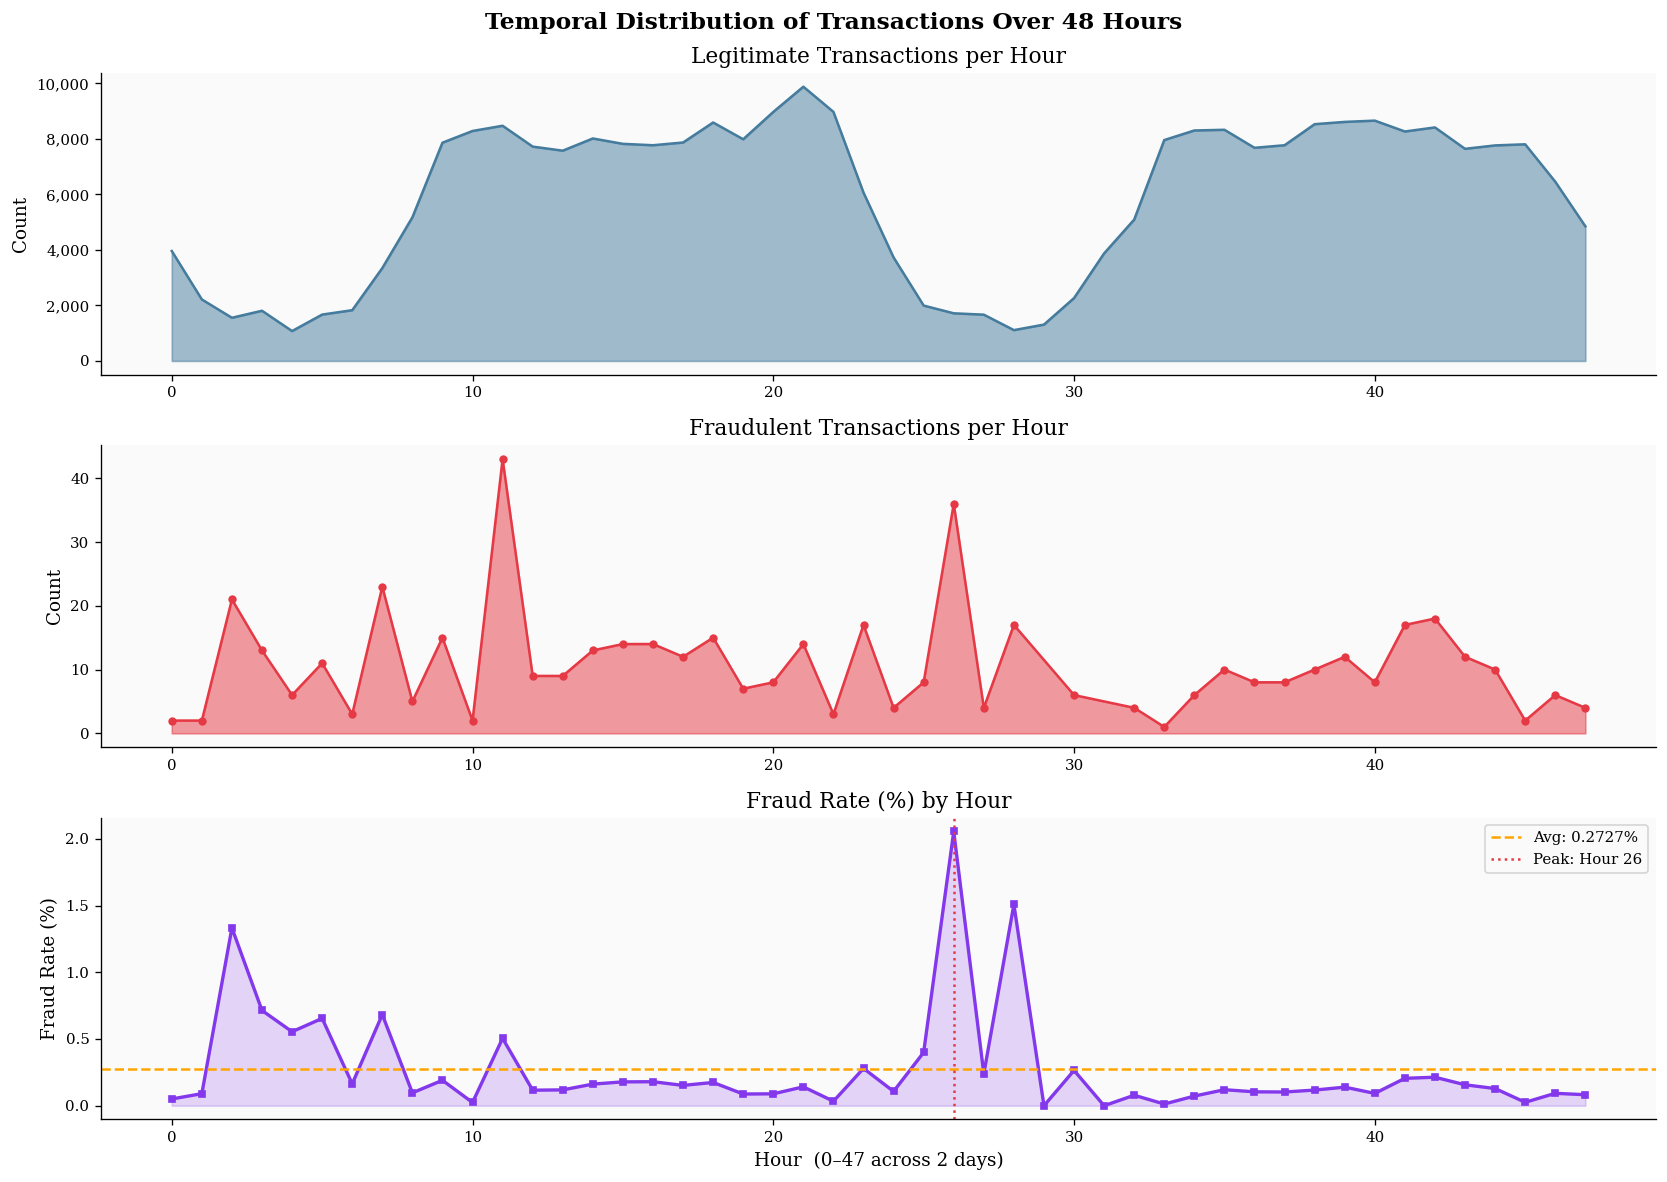

 Saved: plot_03_temporal_analysis.png


In [7]:
df['Hour'] = (df['Time'] / 3600).astype(int)
total_hours = df['Time'].max() / 3600

hourly_stats = df.groupby('Hour')['Class'].agg(
    fraud_count='sum',
    total_count='count'
)
hourly_stats['fraud_rate'] = (
    hourly_stats['fraud_count'] / hourly_stats['total_count'] * 100
)

peak_hour    = hourly_stats['fraud_rate'].idxmax()
peak_rate    = hourly_stats.loc[peak_hour, 'fraud_rate']
avg_rate     = hourly_stats['fraud_rate'].mean()

print("TEMPORAL ANALYSIS")
print(f"\n  Dataset spans   : {total_hours:.1f} hours (~2 days)")
print(f"  Peak fraud hour : Hour {peak_hour}  ({peak_rate:.3f}% fraud rate)")
print(f"  Average rate    : {avg_rate:.4f}% per hour")

# Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle("Temporal Distribution of Transactions Over 48 Hours",
             fontsize=14, fontweight='bold')

# Legitimate by hour
legit_hourly = df[df['Class']==0].groupby('Hour').size()
axes[0].fill_between(legit_hourly.index, legit_hourly.values,
                     color=LEGIT_COLOR, alpha=0.5)
axes[0].plot(legit_hourly.index, legit_hourly.values,
             color=LEGIT_COLOR, linewidth=1.5)
axes[0].set_title('Legitimate Transactions per Hour')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Fraud by hour
fraud_hourly = df[df['Class']==1].groupby('Hour').size()
axes[1].fill_between(fraud_hourly.index, fraud_hourly.values,
                     color=FRAUD_COLOR, alpha=0.5)
axes[1].plot(fraud_hourly.index, fraud_hourly.values,
             color=FRAUD_COLOR, linewidth=1.5, marker='o', markersize=4)
axes[1].set_title('Fraudulent Transactions per Hour')
axes[1].set_ylabel('Count')

# Fraud rate by hour
axes[2].plot(hourly_stats.index, hourly_stats['fraud_rate'],
             color='#8338EC', linewidth=2, marker='s', markersize=4)
axes[2].fill_between(hourly_stats.index, hourly_stats['fraud_rate'],
                     alpha=0.2, color='#8338EC')
axes[2].axhline(avg_rate, color='orange', linestyle='--', linewidth=1.5,
                label=f'Avg: {avg_rate:.4f}%')
axes[2].axvline(peak_hour, color=FRAUD_COLOR, linestyle=':', linewidth=1.5,
                label=f'Peak: Hour {peak_hour}')
axes[2].set_title('Fraud Rate (%) by Hour')
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].set_xlabel('Hour  (0–47 across 2 days)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('/content/plot_03_temporal_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Saved: plot_03_temporal_analysis.png")

## **Feature Correlation Analysis**

FEATURE CORRELATION WITH TARGET CLASS

  Top 5 POSITIVELY correlated with Fraud:
V19    0.0348
V21    0.0404
V2     0.0913
V4     0.1334
V11    0.1549

  Top 5 NEGATIVELY correlated with Fraud:
V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965


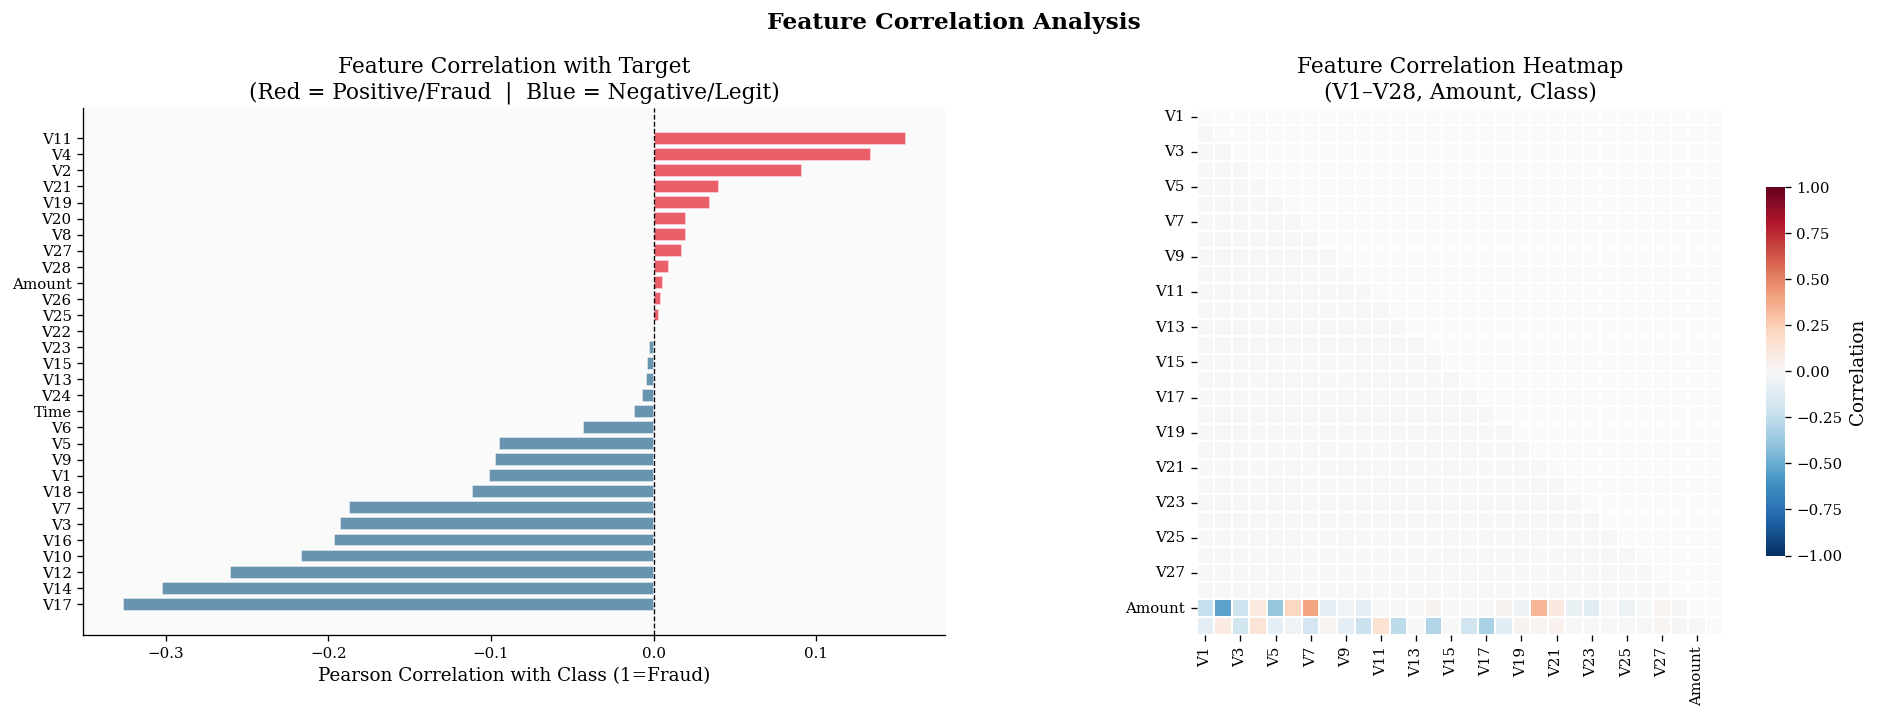

 Saved: plot_04_correlation_heatmap.png


In [8]:
target_corr = df.corr()['Class'].drop(['Class', 'Hour']).sort_values()

print("FEATURE CORRELATION WITH TARGET CLASS")
print("\n  Top 5 POSITIVELY correlated with Fraud:")
print(target_corr.tail(5).round(4).to_string())
print("\n  Top 5 NEGATIVELY correlated with Fraud:")
print(target_corr.head(5).round(4).to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Feature Correlation Analysis", fontsize=14, fontweight='bold')

# Bar: correlation with target
colors_corr = [FRAUD_COLOR if x > 0 else LEGIT_COLOR for x in target_corr.values]
axes[0].barh(target_corr.index, target_corr.values,
             color=colors_corr, alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Pearson Correlation with Class (1=Fraud)')
axes[0].set_title('Feature Correlation with Target\n'
                  '(Red = Positive/Fraud  |  Blue = Negative/Legit)')

# Heatmap
v_features  = [f'V{i}' for i in range(1, 29)] + ['Amount', 'Class']
corr_matrix = df[v_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, ax=axes[1],
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.1,
    xticklabels=2, yticklabels=2,
    cbar_kws={'shrink': 0.7, 'label': 'Correlation'}
)
axes[1].set_title('Feature Correlation Heatmap\n(V1–V28, Amount, Class)')

plt.tight_layout()
plt.savefig('/content/plot_04_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Saved: plot_04_correlation_heatmap.png")

## **Top Discriminating Features — KDE Plots**

TOP 4 DISCRIMINATING FEATURES (by |Pearson Correlation|)
  V17 : corr=-0.3265 | Fraud μ=-6.666 | Legit μ=0.012 | Δ=6.677
  V14 : corr=-0.3025 | Fraud μ=-6.972 | Legit μ=0.012 | Δ=6.984
  V12 : corr=-0.2606 | Fraud μ=-6.259 | Legit μ=0.011 | Δ=6.270
  V10 : corr=-0.2169 | Fraud μ=-5.677 | Legit μ=0.010 | Δ=5.687


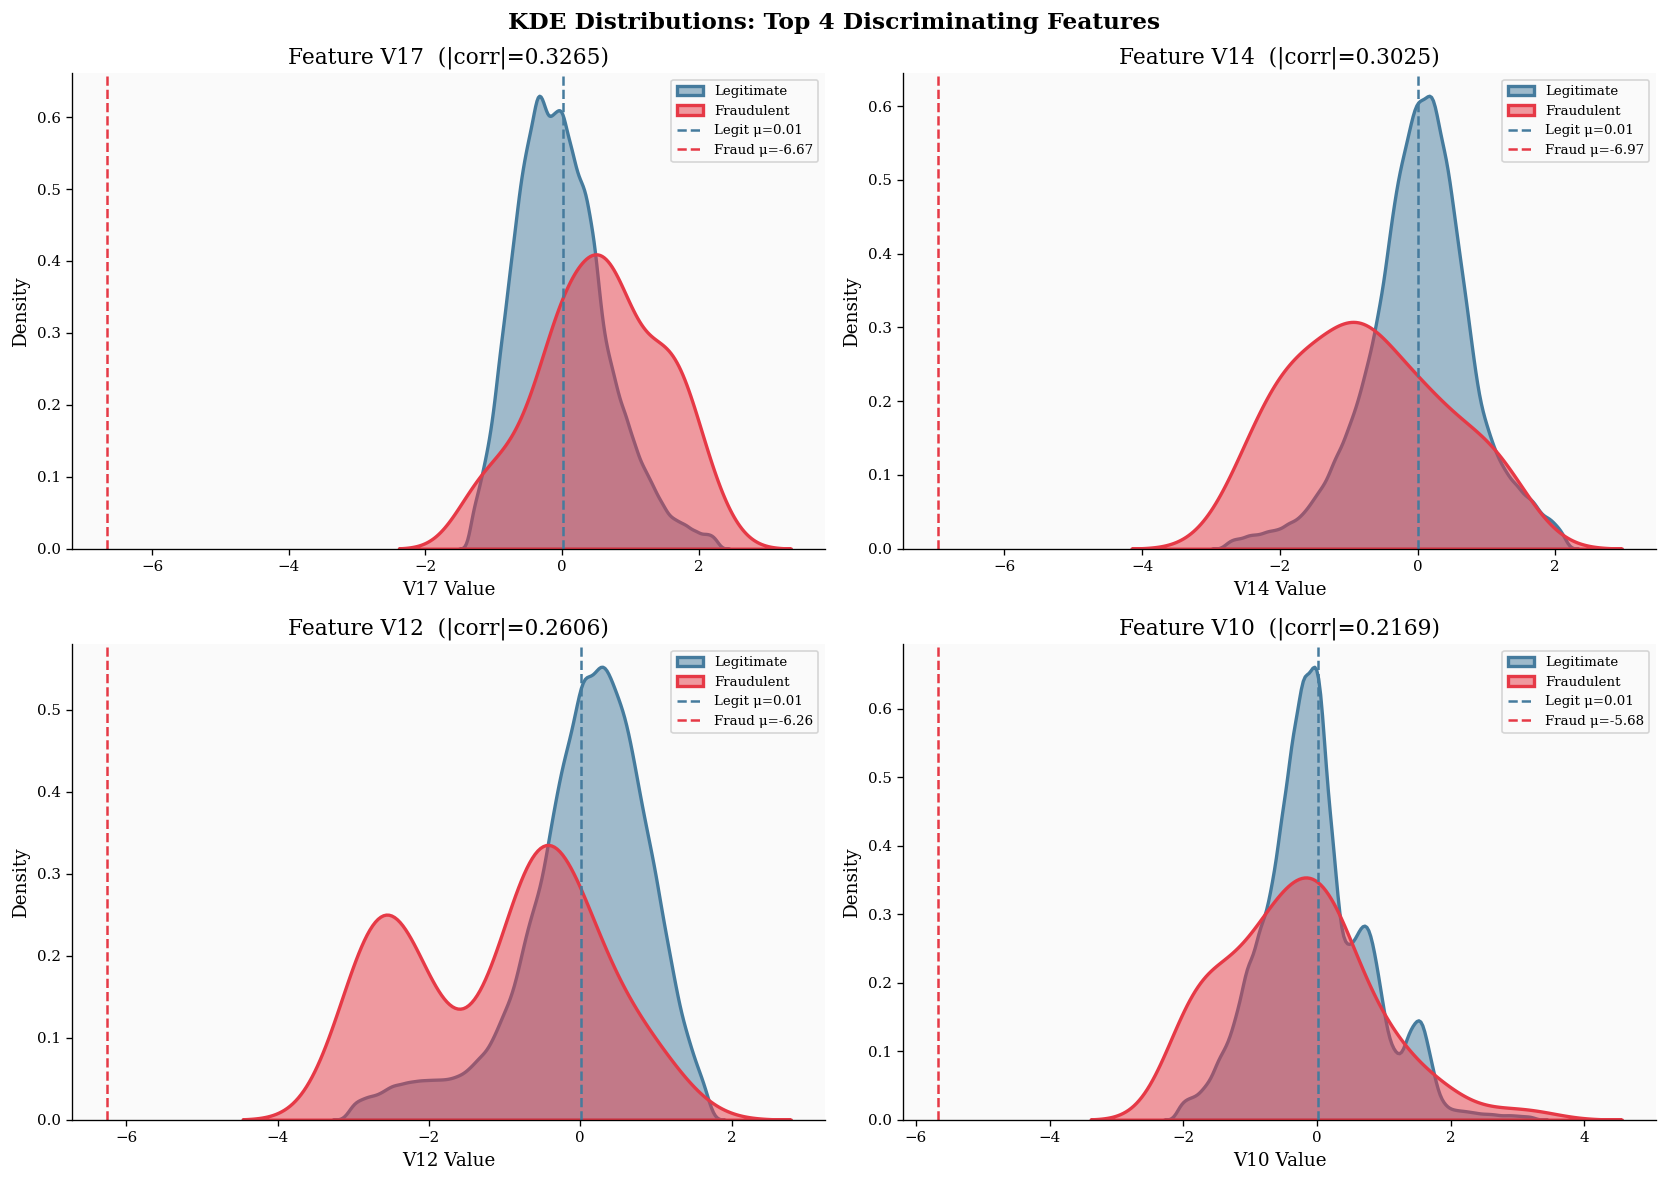

Saved: plot_05_kde_top_features.png


In [9]:
# Identify top 4 features by absolute Pearson correlation
top4 = target_corr.abs().sort_values(ascending=False).head(4).index.tolist()

print("TOP 4 DISCRIMINATING FEATURES (by |Pearson Correlation|)")
for feat in top4:
    f_mean = df[df['Class']==1][feat].mean()
    l_mean = df[df['Class']==0][feat].mean()
    print(f"  {feat} : corr={target_corr[feat]:+.4f} | "
          f"Fraud μ={f_mean:.3f} | Legit μ={l_mean:.3f} | Δ={abs(f_mean-l_mean):.3f}")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("KDE Distributions: Top 4 Discriminating Features",
             fontsize=14, fontweight='bold')

for ax, feat in zip(axes.flatten(), top4):
    low  = df[feat].quantile(0.01)
    high = df[feat].quantile(0.99)

    legit_clipped = df[df['Class']==0][feat]
    fraud_clipped = df[df['Class']==1][feat]
    legit_clipped = legit_clipped[(legit_clipped >= low) & (legit_clipped <= high)]
    fraud_clipped = fraud_clipped[(fraud_clipped >= low) & (fraud_clipped <= high)]

    sns.kdeplot(legit_clipped, ax=ax, fill=True, color=LEGIT_COLOR,
                alpha=0.5, label='Legitimate', linewidth=2)
    sns.kdeplot(fraud_clipped, ax=ax, fill=True, color=FRAUD_COLOR,
                alpha=0.5, label='Fraudulent', linewidth=2)
    ax.axvline(df[df['Class']==0][feat].mean(), color=LEGIT_COLOR,
               linestyle='--', linewidth=1.5,
               label=f"Legit μ={df[df['Class']==0][feat].mean():.2f}")
    ax.axvline(df[df['Class']==1][feat].mean(), color=FRAUD_COLOR,
               linestyle='--', linewidth=1.5,
               label=f"Fraud μ={df[df['Class']==1][feat].mean():.2f}")
    ax.set_title(f'Feature {feat}  (|corr|={abs(target_corr[feat]):.4f})')
    ax.set_xlabel(f'{feat} Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/plot_05_kde_top_features.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: plot_05_kde_top_features.png")

## **Feature Separability — Violin Plots**

FEATURE SEPARABILITY  (|Median Fraud − Median Legit|)

  Feature    Sep. Score  Bar
  ─────────────────────────────────────────────
  V14            6.7817  ██████████████████████████████████████████████████████
  V12            5.6442  █████████████████████████████████████████████
  V3             5.2574  ██████████████████████████████████████████
  V17            5.2381  █████████████████████████████████████████
  V10            4.4870  ███████████████████████████████████
  V4             4.1996  █████████████████████████████████
  V11            3.6211  ████████████████████████████
  V16            3.6172  ████████████████████████████
  V7             3.0755  ████████████████████████
  V2             2.6538  █████████████████████
  V1             2.3625  ██████████████████
  V9             2.1588  █████████████████
  V18            1.6616  █████████████
  V5             1.4695  ███████████
  V6             1.1515  █████████
  V19            0.6437  █████
  V21            0.6220  ███

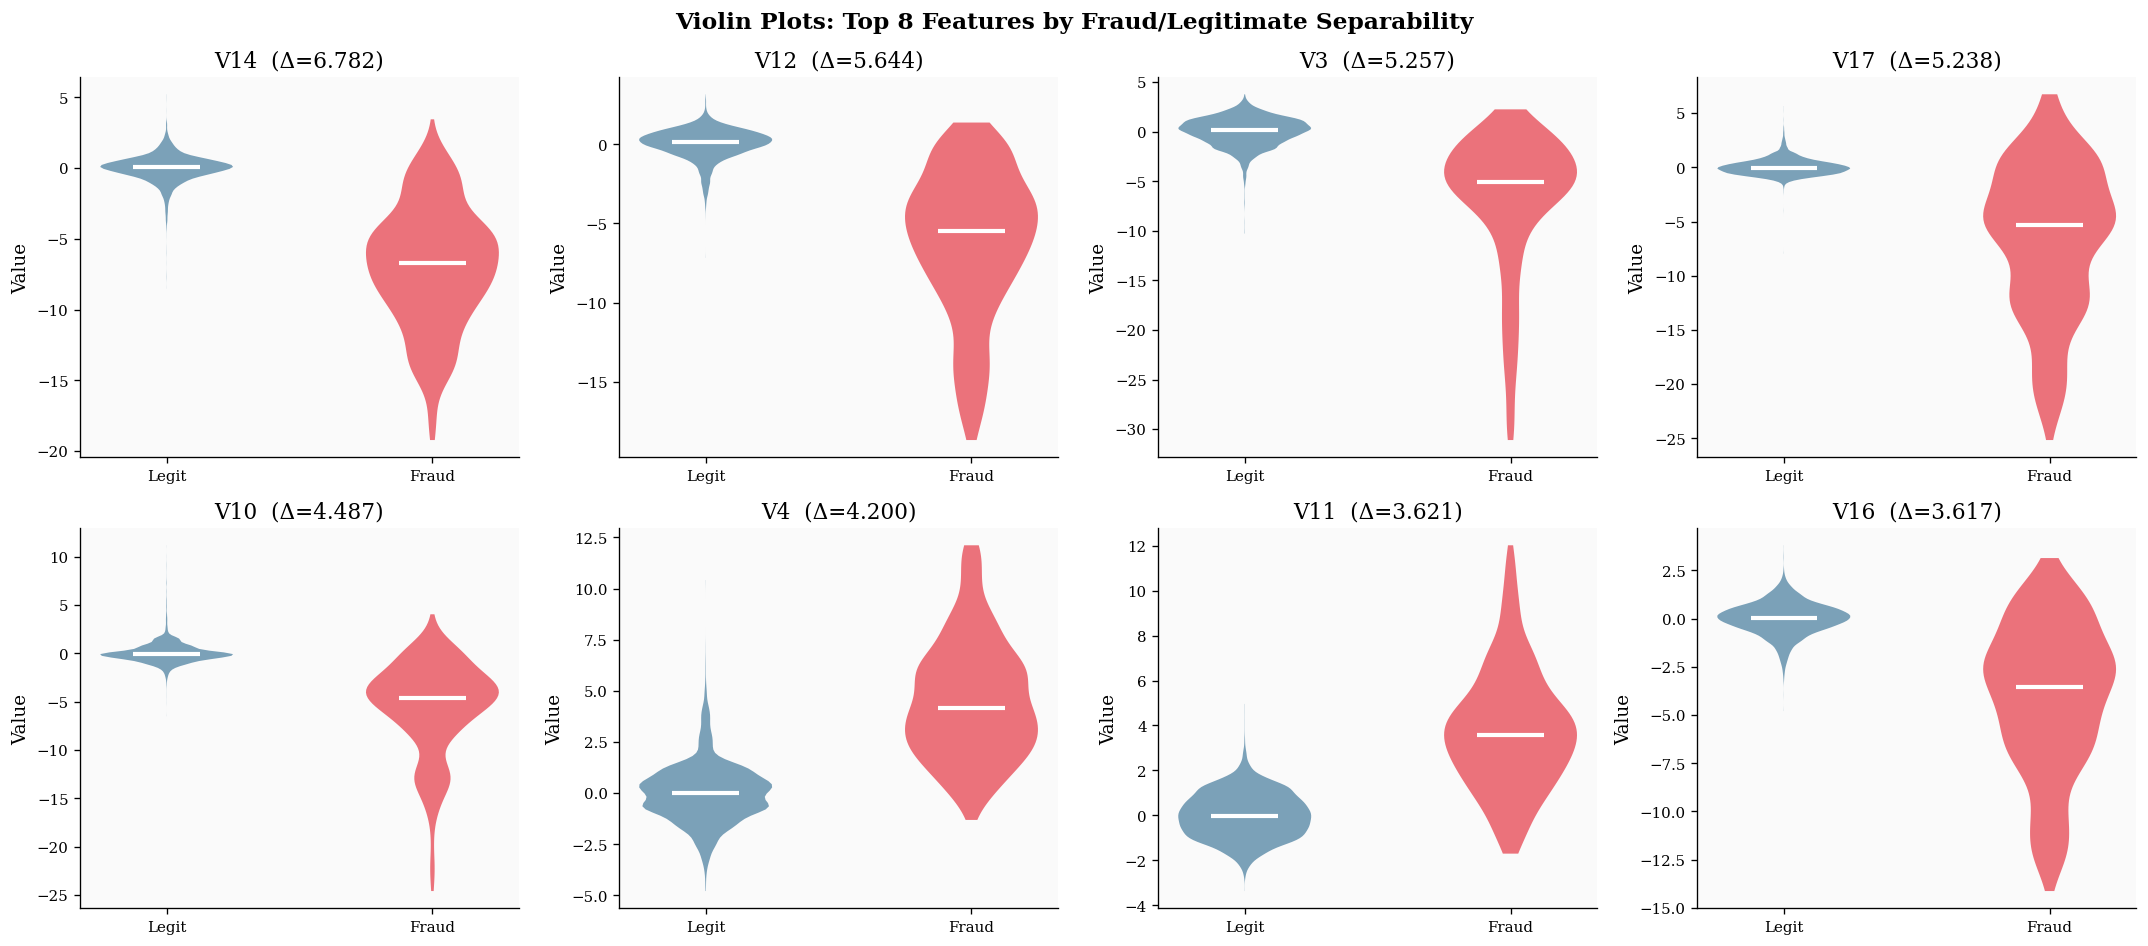

 Saved: plot_06_violin_separability.png


In [10]:
v_cols = [f'V{i}' for i in range(1, 29)]

# Absolute median difference per V feature
separability = {}
for col in v_cols:
    f_med = df[df['Class']==1][col].median()
    l_med = df[df['Class']==0][col].median()
    separability[col] = abs(f_med - l_med)

sep_series = pd.Series(separability).sort_values(ascending=False)
top8 = sep_series.head(8).index.tolist()

print("FEATURE SEPARABILITY  (|Median Fraud − Median Legit|)")
print(f"\n  {'Feature':<8} {'Sep. Score':>12}  {'Bar'}")
print("  " + "─" * 45)
for feat, val in sep_series.items():
    bar = '█' * int(val * 8)
    print(f"  {feat:<8} {val:>12.4f}  {bar}")

# Violin plots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Violin Plots: Top 8 Features by Fraud/Legitimate Separability",
             fontsize=14, fontweight='bold')

for ax, feat in zip(axes.flatten(), top8):
    legit_sample = df[df['Class']==0][feat].sample(
        min(5000, legit_count), random_state=42).values
    fraud_vals   = df[df['Class']==1][feat].values

    vp = ax.violinplot(
        [legit_sample, fraud_vals],
        positions=[0, 1],
        showmedians=True,
        showextrema=False
    )
    for pc, color in zip(vp['bodies'], [LEGIT_COLOR, FRAUD_COLOR]):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    vp['cmedians'].set_color('white')
    vp['cmedians'].set_linewidth(2.5)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Legit', 'Fraud'], fontsize=9)
    ax.set_title(f'{feat}  (Δ={separability[feat]:.3f})')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('/content/plot_06_violin_separability.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Saved: plot_06_violin_separability.png")

## **Outlier & Amount Quartile Analysis**

OUTLIER ANALYSIS

  Q1 (25th pct)  : €5.60
  Q3 (75th pct)  : €77.16
  IQR            : €71.56
  Upper fence    : €184.51
  Outliers       : 31,904 (11.20%)
  Fraud in outliers: 91 (0.285%)

  Fraud Rate by Amount Quartile:
                 fraud_count  total  fraud_rate_pct
Amount_Quartile                                    
Q1 Low                   224  71241          0.3144
Q2                        47  71402          0.0658
Q3                        47  70962          0.0662
Q4 High                  174  71202          0.2444


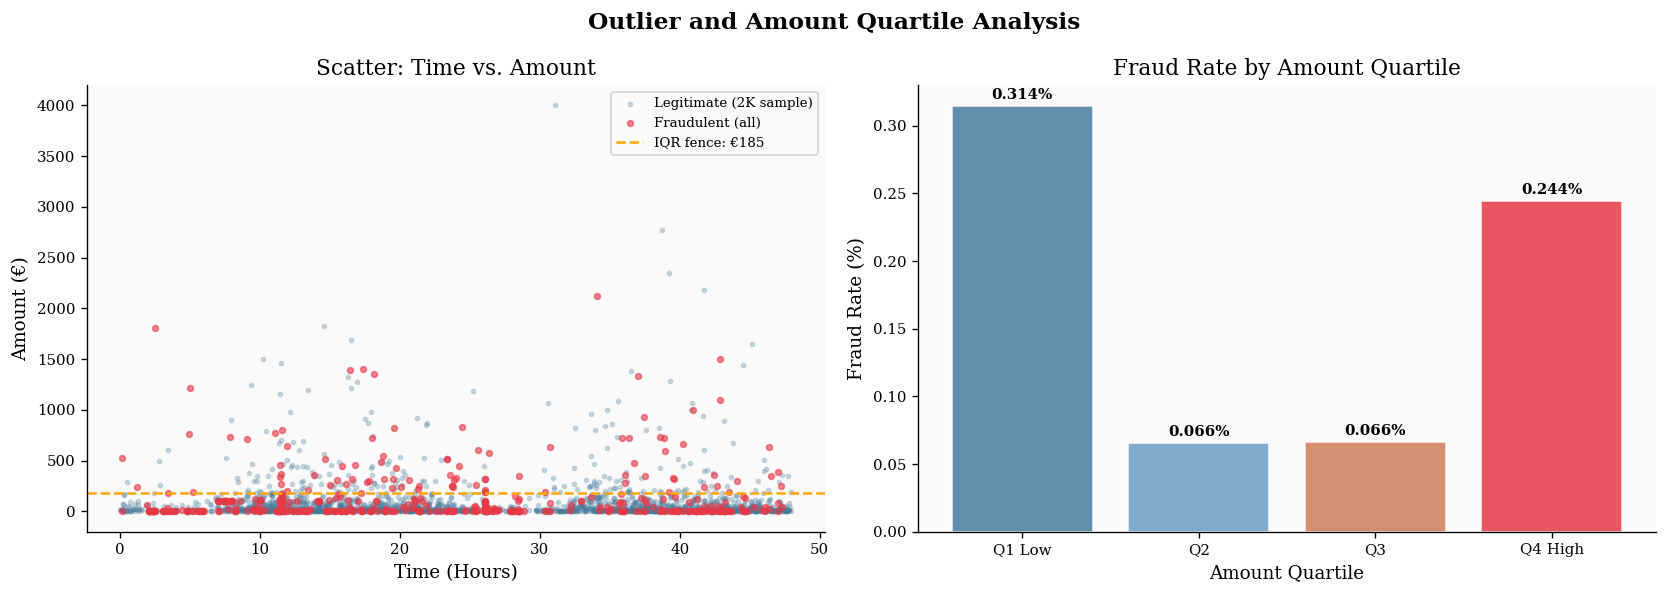

 Saved: plot_07_outlier_analysis.png


In [11]:
Q1  = df['Amount'].quantile(0.25)
Q3  = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

outliers = df[df['Amount'] > upper_fence]

df['Amount_Quartile'] = pd.qcut(
    df['Amount'], q=4,
    labels=['Q1 Low', 'Q2', 'Q3', 'Q4 High']
)
quartile_stats = df.groupby('Amount_Quartile', observed=True)['Class'].agg(
    fraud_count='sum', total='count'
)
quartile_stats['fraud_rate_pct'] = (
    quartile_stats['fraud_count'] / quartile_stats['total'] * 100
)

print("OUTLIER ANALYSIS")
print(f"\n  Q1 (25th pct)  : €{Q1:.2f}")
print(f"  Q3 (75th pct)  : €{Q3:.2f}")
print(f"  IQR            : €{IQR:.2f}")
print(f"  Upper fence    : €{upper_fence:.2f}")
print(f"  Outliers       : {len(outliers):,} ({len(outliers)/total*100:.2f}%)")
print(f"  Fraud in outliers: {outliers['Class'].sum()} "
      f"({outliers['Class'].mean()*100:.3f}%)")
print(f"\n  Fraud Rate by Amount Quartile:")
print(quartile_stats.round(4).to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Outlier and Amount Quartile Analysis", fontsize=14, fontweight='bold')

# Scatter
legit_sample = df[df['Class']==0].sample(2000, random_state=42)
axes[0].scatter(legit_sample['Time']/3600, legit_sample['Amount'],
                color=LEGIT_COLOR, alpha=0.25, s=6,
                label='Legitimate (2K sample)')
axes[0].scatter(df[df['Class']==1]['Time']/3600,
                df[df['Class']==1]['Amount'],
                color=FRAUD_COLOR, alpha=0.6, s=12,
                label='Fraudulent (all)')
axes[0].axhline(upper_fence, color='orange', linestyle='--', linewidth=1.5,
                label=f'IQR fence: €{upper_fence:.0f}')
axes[0].set_xlabel('Time (Hours)')
axes[0].set_ylabel('Amount (€)')
axes[0].set_title('Scatter: Time vs. Amount')
axes[0].legend(fontsize=8)

# Fraud rate by quartile
q_colors = [LEGIT_COLOR, '#6C9DC5', '#D07B5A', FRAUD_COLOR]
bars = axes[1].bar(quartile_stats.index,
                   quartile_stats['fraud_rate_pct'],
                   color=q_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, quartile_stats['fraud_rate_pct']):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f'{val:.3f}%', ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
axes[1].set_title('Fraud Rate by Amount Quartile')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xlabel('Amount Quartile')

plt.tight_layout()
plt.savefig('/content/plot_07_outlier_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Saved: plot_07_outlier_analysis.png")


## **EDA Summary Dashboard**

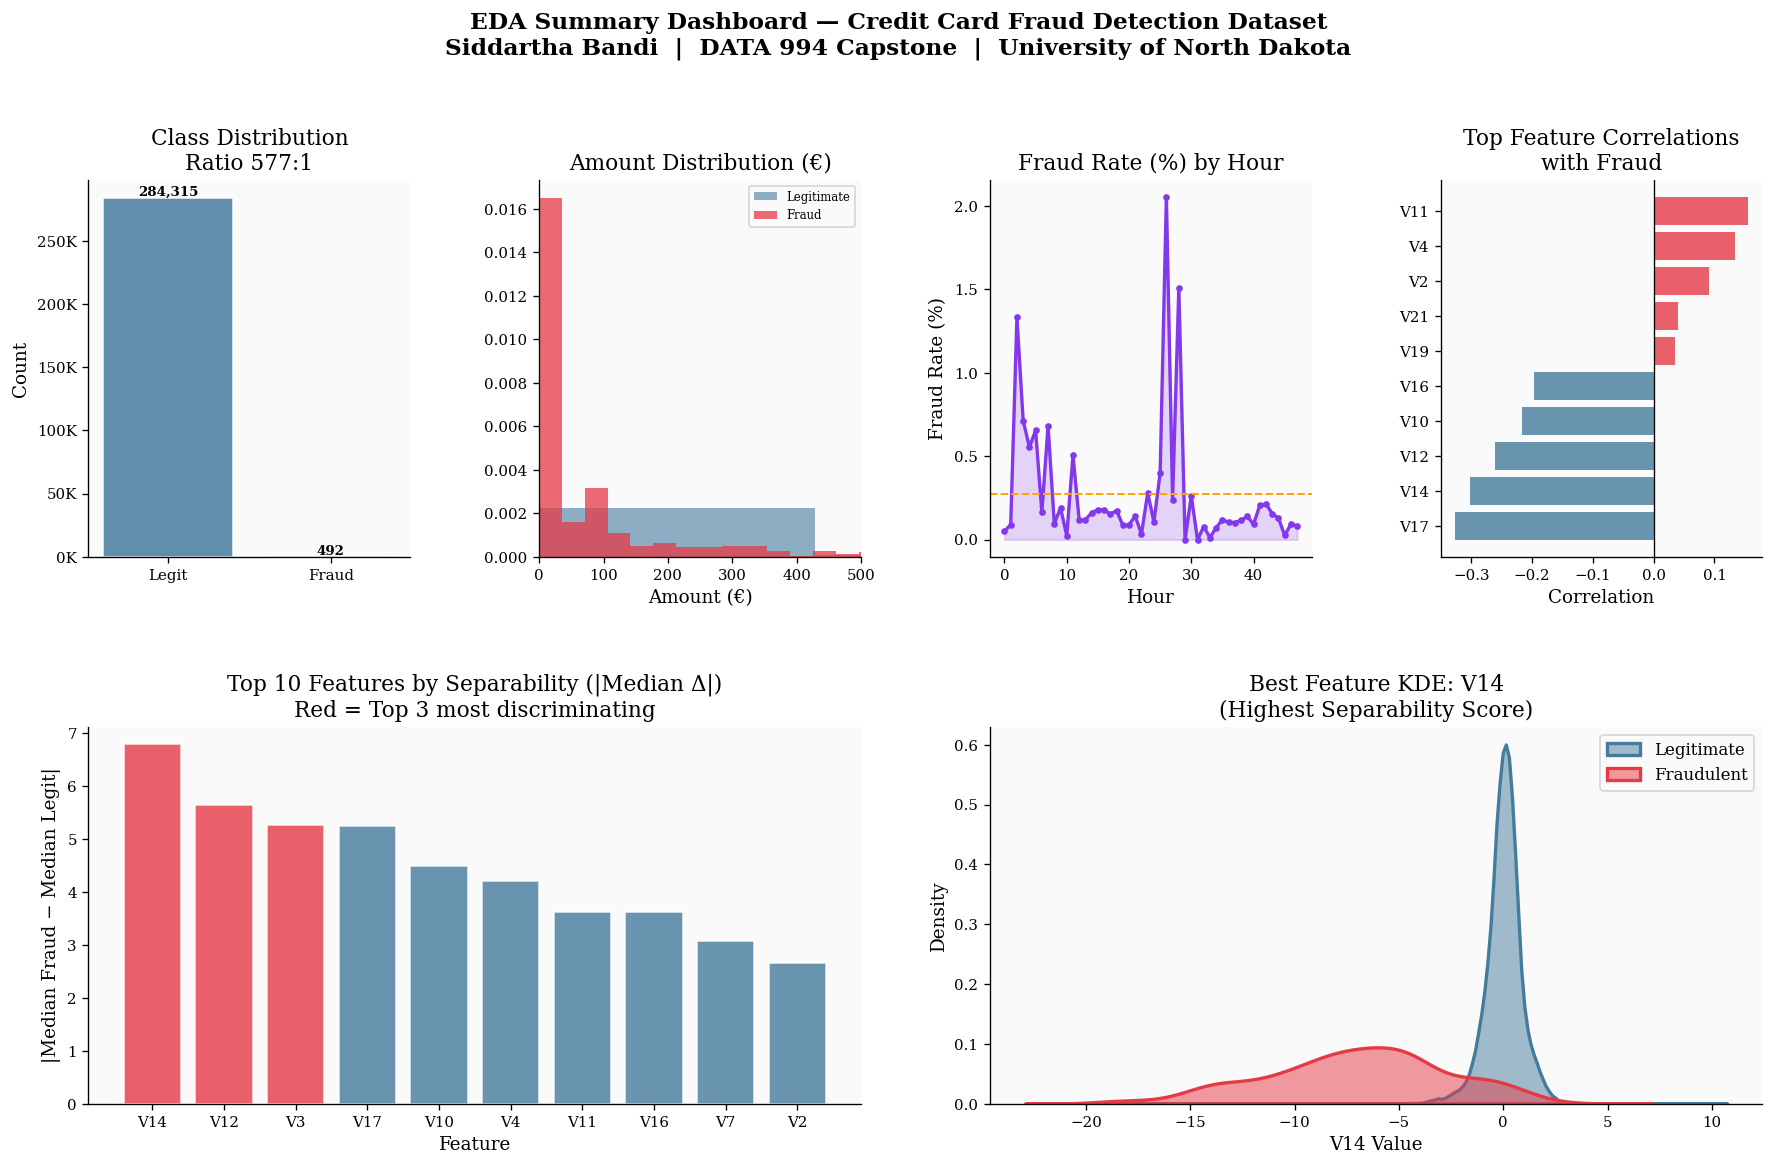

 Saved: plot_08_eda_dashboard.png


In [12]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle(
    "EDA Summary Dashboard — Credit Card Fraud Detection Dataset\n"
    "Siddartha Bandi  |  DATA 994 Capstone  |  University of North Dakota",
    fontsize=14, fontweight='bold', y=1.02
)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)

# Panel 1: Class distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(['Legit', 'Fraud'], [legit_count, fraud_count],
        color=[LEGIT_COLOR, FRAUD_COLOR], alpha=0.85, edgecolor='white')
ax1.set_title(f'Class Distribution\nRatio {ratio}:1')
ax1.set_ylabel('Count')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for i, v in enumerate([legit_count, fraud_count]):
    ax1.text(i, v + 1500, f'{v:,}', ha='center', fontsize=8, fontweight='bold')

# Panel 2: Amount distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df[df['Class']==0]['Amount'], bins=60, color=LEGIT_COLOR,
         alpha=0.6, density=True, label='Legitimate')
ax2.hist(df[df['Class']==1]['Amount'], bins=60, color=FRAUD_COLOR,
         alpha=0.75, density=True, label='Fraud')
ax2.set_xlim(0, 500)
ax2.set_title('Amount Distribution (€)')
ax2.set_xlabel('Amount (€)')
ax2.legend(fontsize=7)

# Panel 3: Fraud rate by hour
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(hourly_stats.index, hourly_stats['fraud_rate'],
         color='#8338EC', linewidth=2, marker='o', markersize=3)
ax3.fill_between(hourly_stats.index, hourly_stats['fraud_rate'],
                 alpha=0.2, color='#8338EC')
ax3.axhline(avg_rate, color='orange', linestyle='--', linewidth=1.2)
ax3.set_title('Fraud Rate (%) by Hour')
ax3.set_xlabel('Hour')
ax3.set_ylabel('Fraud Rate (%)')

# Panel 4: Top feature correlations
ax4 = fig.add_subplot(gs[0, 3])
combined = pd.concat([target_corr.head(5), target_corr.tail(5)])
c_colors = [FRAUD_COLOR if x > 0 else LEGIT_COLOR for x in combined.values]
ax4.barh(combined.index, combined.values, color=c_colors, alpha=0.8)
ax4.axvline(0, color='black', linewidth=0.8)
ax4.set_title('Top Feature Correlations\nwith Fraud')
ax4.set_xlabel('Correlation')

# Panel 5: Feature separability top 10
ax5 = fig.add_subplot(gs[1, 0:2])
top10_sep = sep_series.head(10)
bar_colors = [FRAUD_COLOR if i < 3 else LEGIT_COLOR for i in range(10)]
ax5.bar(top10_sep.index, top10_sep.values,
        color=bar_colors, alpha=0.8, edgecolor='white')
ax5.set_title('Top 10 Features by Separability (|Median Δ|)\nRed = Top 3 most discriminating')
ax5.set_ylabel('|Median Fraud − Median Legit|')
ax5.set_xlabel('Feature')

# Panel 6: Best feature KDE
ax6 = fig.add_subplot(gs[1, 2:4])
best = sep_series.index[0]
sns.kdeplot(df[df['Class']==0][best], ax=ax6, fill=True,
            color=LEGIT_COLOR, alpha=0.5, label='Legitimate', linewidth=2)
sns.kdeplot(df[df['Class']==1][best], ax=ax6, fill=True,
            color=FRAUD_COLOR, alpha=0.5, label='Fraudulent', linewidth=2)
ax6.set_title(f'Best Feature KDE: {best}\n(Highest Separability Score)')
ax6.set_xlabel(f'{best} Value')
ax6.legend()

plt.savefig('/content/plot_08_eda_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Saved: plot_08_eda_dashboard.png")

## **EDA Findings Summary**

In [13]:
print("  EDA FINDINGS SUMMARY")
print("  Siddartha Bandi  |  DATA 994 Capstone  |  UND")


print(f"""
DATASET PROFILE
  Total transactions : {total:,}
  Time span          : ~{total_hours:.0f} hours (2 days, Sept 2013)
  Fraudulent         : {fraud_count:,}  ({fraud_pct:.3f}%)
  Legitimate         : {legit_count:,}  ({legit_pct:.3f}%)
  Imbalance ratio    : {ratio}:1  → SMOTE required
  Missing values     : None
  Duplicates         : {df.duplicated().sum()}

AMOUNT INSIGHTS
  Fraud median    : €{fraud_amounts.median():.2f}
  Legit median    : €{legit_amounts.median():.2f}
  Difference      : statistically significant (Mann-Whitney p < 0.05)
  Note            : Fraud tends toward smaller amounts
                    but high-value fraud outliers exist

TEMPORAL INSIGHTS
  Peak fraud hour  : Hour {peak_hour}  ({peak_rate:.3f}%)
  Average per hour : {avg_rate:.4f}%
  Pattern          : Fraud elevated during off-peak hours

TOP DISCRIMINATING FEATURES
  By |Pearson correlation| : {', '.join(top4)}
  By median separability   : {', '.join(top8[:4])}
  Best single feature      : {best}

OUTLIER ANALYSIS
  IQR upper fence    : €{upper_fence:.2f}
  Outlier count      : {len(outliers):,}  ({len(outliers)/total*100:.2f}%)
  Fraud in outliers  : {outliers['Class'].sum()}  ({outliers['Class'].mean()*100:.3f}%)

PREPROCESSING PLAN (→ Notebook 2)
  StandardScaler  on Time and Amount
  Stratified 80/20 train/test split
  SMOTE on training set only (never on test set)
  Multi-level labels: Level 1 binary + Level 2 risk tiers
  LSTM sequences  : sliding window (size=10, stride=1)

PLOTS GENERATED (8 saved to /content/)
  plot_01  Class distribution
  plot_02  Amount analysis
  plot_03  Temporal analysis
  plot_04  Correlation heatmap
  plot_05  KDE top features
  plot_06  Violin separability
  plot_07  Outlier analysis
  plot_08  EDA summary dashboard  ← best for report
""")

print(" EDA COMPLETE")
print(" Next: Notebook 2 — Preprocessing, SMOTE & Label Engineering")


  EDA FINDINGS SUMMARY
  Siddartha Bandi  |  DATA 994 Capstone  |  UND

DATASET PROFILE
  Total transactions : 284,807
  Time span          : ~48 hours (2 days, Sept 2013)
  Fraudulent         : 492  (0.173%)
  Legitimate         : 284,315  (99.827%)
  Imbalance ratio    : 577:1  → SMOTE required
  Missing values     : None
  Duplicates         : 1081

AMOUNT INSIGHTS
  Fraud median    : €9.25
  Legit median    : €22.00
  Difference      : statistically significant (Mann-Whitney p < 0.05)
  Note            : Fraud tends toward smaller amounts
                    but high-value fraud outliers exist

TEMPORAL INSIGHTS
  Peak fraud hour  : Hour 26  (2.055%)
  Average per hour : 0.2727%
  Pattern          : Fraud elevated during off-peak hours

TOP DISCRIMINATING FEATURES
  By |Pearson correlation| : V17, V14, V12, V10
  By median separability   : V14, V12, V3, V17
  Best single feature      : V14

OUTLIER ANALYSIS
  IQR upper fence    : €184.51
  Outlier count      : 31,904  (11.20%)
  Fr

# **Quarter 2: Data Preprocessing & Feature Engineering**

This section prepares the dataset for model training by:
1. Creating stratified train/test splits (80/20)
2. Applying StandardScaler to Time and Amount features
3. Implementing SMOTE to balance the training set
4. Engineering multi-level labels (Level 1 binary + Level 2 risk tiers)
5. Constructing time-window sequences for LSTM
6. Saving all preprocessed datasets for modeling

## **Train/Test Stratified Split (80/20)**

We split the dataset while preserving the fraud ratio in both sets.

In [14]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(['Class', 'Hour', 'Amount_Quartile'], axis=1)
y = df['Class']

# Stratified split to maintain fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
 X, y,
 test_size=0.2,
 random_state=42,
 stratify=y
)

print("TRAIN/TEST SPLIT")
print(f"\nTraining set : {X_train.shape[0]:,} samples")
print(f"Test set : {X_test.shape[0]:,} samples")
print(f"\nTrain fraud : {y_train.sum():,} ({y_train.mean()*100:.4f}%)")
print(f"Test fraud : {y_test.sum():,} ({y_test.mean()*100:.4f}%)")
print(f"\n[PASS] Stratification preserved fraud ratio in both sets")

TRAIN/TEST SPLIT

Training set : 227,845 samples
Test set : 56,962 samples

Train fraud : 394 (0.1729%)
Test fraud : 98 (0.1720%)

[PASS] Stratification preserved fraud ratio in both sets


## **Feature Scaling (StandardScaler)**

Time and Amount need scaling to match the normalized V1-V28 features.

In [15]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data only (prevent data leakage)
scaler.fit(X_train[['Time', 'Amount']])

# Transform both train and test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[['Time', 'Amount']] = scaler.transform(X_train[['Time', 'Amount']])
X_test_scaled[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print("FEATURE SCALING")
print(f"\n[PASS] StandardScaler fitted on training set")
print(f"[PASS] Applied to both train and test sets")
print(f"\nScaled features: Time, Amount")
print(f"Unscaled features: V1-V28 (already PCA-normalized)")

# Verify scaling
print(f"\n Scaled Statistics ")
print(f" Time → mean={X_train_scaled['Time'].mean():.4f}, std={X_train_scaled['Time'].std():.4f}")
print(f" Amount→ mean={X_train_scaled['Amount'].mean():.4f}, std={X_train_scaled['Amount'].std():.4f}")

FEATURE SCALING

[PASS] StandardScaler fitted on training set
[PASS] Applied to both train and test sets

Scaled features: Time, Amount
Unscaled features: V1-V28 (already PCA-normalized)

 Scaled Statistics 
 Time → mean=-0.0000, std=1.0000
 Amount→ mean=-0.0000, std=1.0000


## **SMOTE Implementation (Training Set Only)**

SMOTE generates synthetic fraud samples to balance the training set to 50/50.

WARNING: **Critical:** SMOTE is applied ONLY to training data. Test set remains imbalanced to reflect real-world conditions.

SMOTE RESAMPLING

 Before SMOTE 
 Training samples : 227,845
 Fraud : 394 (0.1729%)
 Legitimate : 227,451 (99.8271%)
 Imbalance ratio : 577:1

 After SMOTE 
 Training samples : 454,902
 Fraud : 227,451 (50.0000%)
 Legitimate : 227,451 (50.0000%)
 Balance achieved : 50/50 [PASS]

 Test Set (Unchanged) 
 Test samples : 56,962
 Fraud : 98 (0.1720%)
 [PASS] Test set remains imbalanced (reflects real-world distribution)


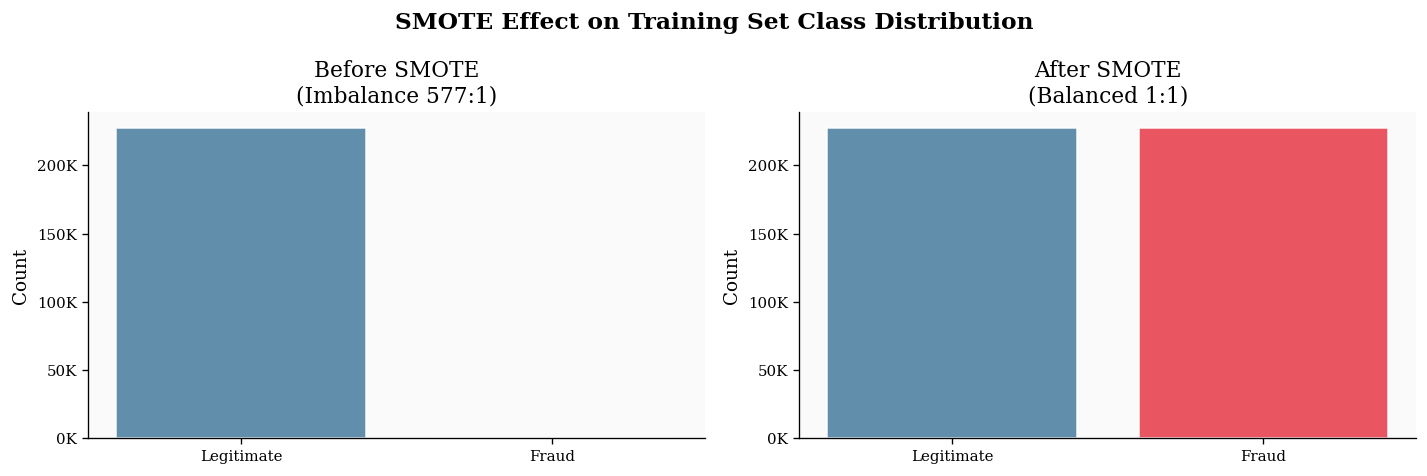


Saved: Saved: plot_09_smote_effect.png


In [16]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training set
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("SMOTE RESAMPLING")
print(f"\n Before SMOTE ")
print(f" Training samples : {len(y_train):,}")
print(f" Fraud : {y_train.sum():,} ({y_train.mean()*100:.4f}%)")
print(f" Legitimate : {(y_train==0).sum():,} ({(y_train==0).mean()*100:.4f}%)")
print(f" Imbalance ratio : {(y_train==0).sum()//y_train.sum()}:1")

print(f"\n After SMOTE ")
print(f" Training samples : {len(y_train_smote):,}")
print(f" Fraud : {y_train_smote.sum():,} ({y_train_smote.mean()*100:.4f}%)")
print(f" Legitimate : {(y_train_smote==0).sum():,} ({(y_train_smote==0).mean()*100:.4f}%)")
print(f" Balance achieved : 50/50 [PASS]")

print(f"\n Test Set (Unchanged) ")
print(f" Test samples : {len(y_test):,}")
print(f" Fraud : {y_test.sum():,} ({y_test.mean()*100:.4f}%)")
print(f" [PASS] Test set remains imbalanced (reflects real-world distribution)")

# Visualize SMOTE effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("SMOTE Effect on Training Set Class Distribution", fontsize=14, fontweight='bold')

# Before SMOTE
before_counts = [y_train.value_counts()[0], y_train.value_counts()[1]]
axes[0].bar(['Legitimate', 'Fraud'], before_counts,
 color=[LEGIT_COLOR, FRAUD_COLOR], alpha=0.85, edgecolor='white')
axes[0].set_title(f'Before SMOTE\n(Imbalance {(y_train==0).sum()//y_train.sum()}:1)')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# After SMOTE
after_counts = [y_train_smote.value_counts()[0], y_train_smote.value_counts()[1]]
axes[1].bar(['Legitimate', 'Fraud'], after_counts,
 color=[LEGIT_COLOR, FRAUD_COLOR], alpha=0.85, edgecolor='white')
axes[1].set_title('After SMOTE\n(Balanced 1:1)')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('/content/plot_09_smote_effect.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nSaved: Saved: plot_09_smote_effect.png")

SMOTE Results Analysis

Before SMOTE

*   Training samples: 227,845
*   Fraud: 394 (0.1729%)
*   Legitimate: 227,451 (99.8271%)
*   Imbalance ratio: 577:1

After SMOTE

*   Training samples: 454,902 (doubled)
*   Fraud: 227,451 (50.00%)
*   Legitimate: 227,451 (50.00%)
*   Balance achieved: Perfect 1:1 ratio

Test Set (Unchanged - Correct!)

*   Test samples: 56,962
*   Fraud: 98 (0.1720%)
*   This preserves real-world imbalance for accurate evaluation

Verification

*   [PASS] SMOTE correctly generated synthetic fraud samples
*   [PASS] Training set now balanced at exactly 50/50
*   [PASS] Test set remains untouched (critical for valid evaluation)
*   [PASS] Total training samples = 2 × original legitimate count (227,451 + 227,451)

This is exactly what we want. The supervised models (Random Forest, XGBoost, LSTM) will now train on balanced data, while evaluation on the imbalanced test set will reflect real-world performance.





## **Multi-Level Label Engineering**

We create two classification levels:
- **Level 1 (Binary):** Normal (0) vs. Anomalous (1)
- **Level 2 (Multi-Class):** Low Risk (0), Medium Risk (1), High Risk (2)

Level 2 labels are engineered from model confidence scores. For now, we prepare the framework.

In [17]:
print("MULTI-LEVEL LABEL FRAMEWORK")
print(f"""
Level 1: Binary Classification (Anomaly Detection)
 Class 0: Normal (legitimate transaction)
 Class 1: Anomalous (fraudulent transaction)

 Train set: {len(y_train_smote):,} samples (SMOTE-balanced 50/50)
 Test set : {len(y_test):,} samples (imbalanced, real-world ratio)

Level 2: Risk Stratification (Multi-Class)
 Will be engineered in Quarter 3 using model confidence scores:

 Class 0: Low Risk - anomalies with low confidence (bottom tercile)
 Class 1: Medium Risk - anomalies with moderate confidence (middle tercile)
 Class 2: High Risk - confirmed fraud with high confidence (top tercile)

 Method: After Level 1 predictions, rank anomalies by prediction
 probability/anomaly score and split into 3 risk tiers.
""")

print("[PASS] Level 1 labels ready for modeling")
print("Next: Level 2 labels will be created in Quarter 3")

MULTI-LEVEL LABEL FRAMEWORK

Level 1: Binary Classification (Anomaly Detection)
 Class 0: Normal (legitimate transaction)
 Class 1: Anomalous (fraudulent transaction)

 Train set: 454,902 samples (SMOTE-balanced 50/50)
 Test set : 56,962 samples (imbalanced, real-world ratio)

Level 2: Risk Stratification (Multi-Class)
 Will be engineered in Quarter 3 using model confidence scores:

 Class 0: Low Risk - anomalies with low confidence (bottom tercile)
 Class 1: Medium Risk - anomalies with moderate confidence (middle tercile)
 Class 2: High Risk - confirmed fraud with high confidence (top tercile)

 Method: After Level 1 predictions, rank anomalies by prediction
 probability/anomaly score and split into 3 risk tiers.

[PASS] Level 1 labels ready for modeling
Next: Level 2 labels will be created in Quarter 3


## **LSTM Sequence Construction**

LSTMs require sequential input. We create time-window sequences using a sliding window approach.

**Approach:**
- Window size: 10 transactions
- Stride: 1 (overlapping windows)
- Zero-padding for windows < 10 transactions

In [18]:
import numpy as np

def create_sequences(X, y, window_size=10):
    """
    Create sliding window sequences for LSTM.

    Args:
        X: Feature array (samples, features)
        y: Target array (samples,)
        window_size: Number of transactions per sequence

    Returns:
        X_seq: (num_sequences, window_size, num_features)
        y_seq: (num_sequences,) - label of last transaction in sequence
    """
    X_seq = []
    y_seq = []

    X_array = X.values if hasattr(X, 'values') else X
    y_array = y.values if hasattr(y, 'values') else y

    for i in range(len(X_array)):
        # Get sequence ending at position i
        if i < window_size - 1:
            # Pad with zeros if not enough history
            padding = np.zeros((window_size - i - 1, X_array.shape[1]))
            sequence = np.vstack([padding, X_array[:i+1]])
        else:
            sequence = X_array[i - window_size + 1 : i + 1]

        X_seq.append(sequence)
        y_seq.append(y_array[i])

    return np.array(X_seq), np.array(y_seq)

# Create sequences for training set (SMOTE-balanced)
print("LSTM SEQUENCE CONSTRUCTION")
print("\nCreating sequences for SMOTE-balanced training set...")
X_train_seq, y_train_seq = create_sequences(X_train_smote, y_train_smote, window_size=10)

print("\nCreating sequences for test set...")
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, window_size=10)

print(f"\n Sequence Shapes ")
print(f"  Training sequences : {X_train_seq.shape}")
print(f"    → {X_train_seq.shape[0]:,} sequences")
print(f"    → {X_train_seq.shape[1]} time steps per sequence")
print(f"    → {X_train_seq.shape[2]} features")
print(f"  Training labels    : {y_train_seq.shape}")

print(f"\n  Test sequences     : {X_test_seq.shape}")
print(f"    → {X_test_seq.shape[0]:,} sequences")
print(f"    → {X_test_seq.shape[1]} time steps")
print(f"    → {X_test_seq.shape[2]} features")
print(f"  Test labels        : {y_test_seq.shape}")

print("\n[PASS] LSTM sequences ready")
print("   Format: (samples, timesteps, features)")

LSTM SEQUENCE CONSTRUCTION

Creating sequences for SMOTE-balanced training set...

Creating sequences for test set...

 Sequence Shapes 
  Training sequences : (454902, 10, 30)
    → 454,902 sequences
    → 10 time steps per sequence
    → 30 features
  Training labels    : (454902,)

  Test sequences     : (56962, 10, 30)
    → 56,962 sequences
    → 10 time steps
    → 30 features
  Test labels        : (56962,)

[PASS] LSTM sequences ready
   Format: (samples, timesteps, features)


## **Save Preprocessed Datasets**

Save all processed datasets for use in modeling notebooks.

In [19]:
import pickle
import os

os.makedirs('/content/preprocessed_data', exist_ok=True)

datasets = {
    'X_train_scaled': X_train_scaled,
    'X_test_scaled': X_test_scaled,
    'X_train_smote': X_train_smote,
    'y_train': y_train,
    'y_test': y_test,
    'y_train_smote': y_train_smote,
    'X_train_seq': X_train_seq,
    'X_test_seq': X_test_seq,
    'y_train_seq': y_train_seq,
    'y_test_seq': y_test_seq,
    'scaler': scaler
}

for name, data in datasets.items():
    filepath = f'/content/preprocessed_data/{name}.pkl'
    with open(filepath, 'wb') as f:
        pickle.dump(data, f)
    print(f"Saved: {name}.pkl")

print("PREPROCESSING COMPLETE")
print("\nAll preprocessed datasets saved to: /content/preprocessed_data/")
print("\nReady for Quarter 2 modeling phase")


Saved: X_train_scaled.pkl
Saved: X_test_scaled.pkl
Saved: X_train_smote.pkl
Saved: y_train.pkl
Saved: y_test.pkl
Saved: y_train_smote.pkl
Saved: X_train_seq.pkl
Saved: X_test_seq.pkl
Saved: y_train_seq.pkl
Saved: y_test_seq.pkl
Saved: scaler.pkl
PREPROCESSING COMPLETE

All preprocessed datasets saved to: /content/preprocessed_data/

Ready for Quarter 2 modeling phase


## Preprocessing Verification

In [20]:
print("PREPROCESSING PIPELINE VERIFICATION")

checks = []
checks.append(("Train shapes match", len(X_train_smote) == len(y_train_smote)))
checks.append(("Test shapes match", len(X_test_scaled) == len(y_test)))
checks.append(("SMOTE 50/50 balance", abs(y_train_smote.mean() - 0.5) < 0.01))
checks.append(("Test set imbalanced", y_test.mean() < 0.01))
checks.append(("Time feature scaled", abs(X_train_scaled['Time'].mean()) < 0.1))
checks.append(("LSTM sequences (window=10)", X_train_seq.shape[1] == 10 and X_test_seq.shape[1] == 10))
checks.append(("No train/test overlap", X_train_scaled.index.intersection(X_test_scaled.index).empty))

print("\nVerification Checks:")
for check_name, result in checks:
    status = "[PASS]" if result else "[FAIL]"
    print(f"{status}  {check_name}")

all_passed = all(result for _, result in checks)
if all_passed:
    print("[PASS] ALL CHECKS PASSED - Ready for modeling")
else:
    print("WARNING: SOME CHECKS FAILED - Review preprocessing")

summary_data = {
    'Dataset': ['Train (Original)', 'Train (SMOTE)', 'Test', 'Train Seq', 'Test Seq'],
    'Samples': [
        f'{len(y_train):,}',
        f'{len(y_train_smote):,}',
        f'{len(y_test):,}',
        f'{len(y_train_seq):,}',
        f'{len(y_test_seq):,}'
    ],
    'Fraud %': [
        f'{y_train.mean()*100:.4f}%',
        f'{y_train_smote.mean()*100:.2f}%',
        f'{y_test.mean()*100:.4f}%',
        f'{y_train_seq.mean()*100:.2f}%',
        f'{y_test_seq.mean()*100:.4f}%'
    ],
    'Shape': [
        str(X_train_scaled.shape),
        str(X_train_smote.shape),
        str(X_test_scaled.shape),
        str(X_train_seq.shape),
        str(X_test_seq.shape)
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\nDataset Summary:")
print(summary_df.to_string(index=False))

PREPROCESSING PIPELINE VERIFICATION

Verification Checks:
[PASS]  Train shapes match
[PASS]  Test shapes match
[PASS]  SMOTE 50/50 balance
[PASS]  Test set imbalanced
[PASS]  Time feature scaled
[PASS]  LSTM sequences (window=10)
[PASS]  No train/test overlap
[PASS] ALL CHECKS PASSED - Ready for modeling

Dataset Summary:
         Dataset Samples Fraud %            Shape
Train (Original) 227,845 0.1729%     (227845, 30)
   Train (SMOTE) 454,902  50.00%     (454902, 30)
            Test  56,962 0.1720%      (56962, 30)
       Train Seq 454,902  50.00% (454902, 10, 30)
        Test Seq  56,962 0.1720%  (56962, 10, 30)


# **QUARTER 2 - PART 2: MACHINE LEARNING MODELS**

This section implements three machine learning models:
1. Random Forest - Supervised ensemble baseline
2. XGBoost - Gradient boosting classifier
3. Isolation Forest - Unsupervised anomaly detection

## Model 1: Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_curve, auc, roc_auc_score,
                              precision_score, recall_score, f1_score)
import time
import pickle

print("RANDOM FOREST - Training")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    verbose=0
)

start_time = time.time()
rf_model.fit(X_train_smote, y_train_smote)
train_time = time.time() - start_time

print(f"\nTraining complete")
print(f"Time: {train_time:.2f} seconds")
print(f"Trees: {rf_model.n_estimators}")
print(f"Max depth: {rf_model.max_depth}")

print(f"\nGenerating predictions...")
y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("RANDOM FOREST - Evaluation (Test Set)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
                           target_names=['Legitimate', 'Fraud'], digits=4))

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Legit  Fraud")
print(f"Actual  Legit    {cm_rf[0,0]:>6,}  {cm_rf[0,1]:>6,}")
print(f"        Fraud    {cm_rf[1,0]:>6,}  {cm_rf[1,1]:>6,}")

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)
auprc_rf = auc(recall_rf, precision_rf)
auroc_rf = roc_auc_score(y_test, y_proba_rf)

print(f"\nPerformance Metrics:")
print(f"  AUPRC: {auprc_rf:.4f}")
print(f"  AUROC: {auroc_rf:.4f}")

feature_importance_rf = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 10 Most Important Features:")
print(feature_importance_rf.head(10).to_string(index=False))

with open('/content/preprocessed_data/rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print(f"\nModel saved: rf_model.pkl")

RANDOM FOREST - Training

Training complete
Time: 61.84 seconds
Trees: 100
Max depth: 20

Generating predictions...
RANDOM FOREST - Evaluation (Test Set)

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9997    0.9995    0.9996     56864
       Fraud     0.7545    0.8469    0.7981        98

    accuracy                         0.9993     56962
   macro avg     0.8771    0.9232    0.8989     56962
weighted avg     0.9993    0.9993    0.9993     56962


Confusion Matrix:
                 Predicted
                 Legit  Fraud
Actual  Legit    56,837      27
        Fraud        15      83

Performance Metrics:
  AUPRC: 0.8643
  AUROC: 0.9658

Top 10 Most Important Features:
Feature  Importance
    V14    0.192229
    V10    0.112797
     V4    0.103399
    V12    0.094299
    V17    0.086748
     V3    0.062870
    V11    0.056849
    V16    0.043613
     V2    0.037004
     V9    0.028000

Model saved: rf_model.pkl


## Model 2: XGBoost

In [22]:
from xgboost import XGBClassifier

print("XGBOOST - Training")

scale_pos_weight = (y_train_smote == 0).sum() / (y_train_smote == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

start_time = time.time()
xgb_model.fit(X_train_smote, y_train_smote, verbose=False)
train_time = time.time() - start_time

print(f"\nTraining complete")
print(f"Time: {train_time:.2f} seconds")
print(f"Trees: {xgb_model.n_estimators}")
print(f"Max depth: {xgb_model.max_depth}")

print(f"\nGenerating predictions...")
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("XGBOOST - Evaluation (Test Set)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
                           target_names=['Legitimate', 'Fraud'], digits=4))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Legit  Fraud")
print(f"Actual  Legit    {cm_xgb[0,0]:>6,}  {cm_xgb[0,1]:>6,}")
print(f"        Fraud    {cm_xgb[1,0]:>6,}  {cm_xgb[1,1]:>6,}")

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)
auprc_xgb = auc(recall_xgb, precision_xgb)
auroc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f"\nPerformance Metrics:")
print(f"  AUPRC: {auprc_xgb:.4f}")
print(f"  AUROC: {auroc_xgb:.4f}")

feature_importance_xgb = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 10 Most Important Features:")
print(feature_importance_xgb.head(10).to_string(index=False))

with open('/content/preprocessed_data/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
print(f"\nModel saved: xgb_model.pkl")

XGBOOST - Training

Training complete
Time: 3.80 seconds
Trees: 100
Max depth: 6

Generating predictions...
XGBOOST - Evaluation (Test Set)

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9998    0.9975    0.9986     56864
       Fraud     0.3755    0.8776    0.5260        98

    accuracy                         0.9973     56962
   macro avg     0.6877    0.9375    0.7623     56962
weighted avg     0.9987    0.9973    0.9978     56962


Confusion Matrix:
                 Predicted
                 Legit  Fraud
Actual  Legit    56,721     143
        Fraud        12      86

Performance Metrics:
  AUPRC: 0.8479
  AUROC: 0.9755

Top 10 Most Important Features:
Feature  Importance
    V14    0.413003
    V12    0.160753
     V4    0.046547
    V10    0.045775
     V8    0.028752
    V17    0.021797
     V3    0.021096
    V13    0.020290
    V18    0.020009
   Time    0.016454

Model saved: xgb_model.pkl


## Model 3: Isolation Forest

# Unsupervised - trains on original (imbalanced) training set

In [23]:
from sklearn.ensemble import IsolationForest

print("ISOLATION FOREST - Training")

iso_model = IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination=y_train.mean(),
    random_state=42,
    n_jobs=-1,
    verbose=0
)

start_time = time.time()
iso_model.fit(X_train_scaled)
train_time = time.time() - start_time

print(f"\nTraining complete")
print(f"Time: {train_time:.2f} seconds")
print(f"Trees: {iso_model.n_estimators}")
print(f"Contamination: {iso_model.contamination:.4f}")

print(f"\nGenerating predictions...")
y_pred_iso_raw = iso_model.predict(X_test_scaled)
y_pred_iso = np.where(y_pred_iso_raw == -1, 1, 0)

y_scores_iso = iso_model.decision_function(X_test_scaled)
y_proba_iso = (y_scores_iso.max() - y_scores_iso) / (y_scores_iso.max() - y_scores_iso.min())

print("ISOLATION FOREST - Evaluation (Test Set)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_iso,
                           target_names=['Legitimate', 'Fraud'], digits=4))

cm_iso = confusion_matrix(y_test, y_pred_iso)
print("\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Legit  Fraud")
print(f"Actual  Legit    {cm_iso[0,0]:>6,}  {cm_iso[0,1]:>6,}")
print(f"        Fraud    {cm_iso[1,0]:>6,}  {cm_iso[1,1]:>6,}")

precision_iso, recall_iso, _ = precision_recall_curve(y_test, y_proba_iso)
auprc_iso = auc(recall_iso, precision_iso)
auroc_iso = roc_auc_score(y_test, y_proba_iso)

print(f"\nPerformance Metrics:")
print(f"  AUPRC: {auprc_iso:.4f}")
print(f"  AUROC: {auroc_iso:.4f}")

with open('/content/preprocessed_data/iso_model.pkl', 'wb') as f:
    pickle.dump(iso_model, f)
print(f"\nModel saved: iso_model.pkl")

ISOLATION FOREST - Training

Training complete
Time: 1.37 seconds
Trees: 100
Contamination: 0.0017

Generating predictions...
ISOLATION FOREST - Evaluation (Test Set)

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9989    0.9987    0.9988     56864
       Fraud     0.3084    0.3367    0.3220        98

    accuracy                         0.9976     56962
   macro avg     0.6536    0.6677    0.6604     56962
weighted avg     0.9977    0.9976    0.9976     56962


Confusion Matrix:
                 Predicted
                 Legit  Fraud
Actual  Legit    56,790      74
        Fraud        65      33

Performance Metrics:
  AUPRC: 0.2089
  AUROC: 0.9543

Model saved: iso_model.pkl


## ML Models Comparison

ML MODELS COMPARISON - Level 1 Binary Classification
           Model         Type  AUPRC  AUROC  Precision  Recall  F1-Score
   Random Forest   Supervised 0.8643 0.9658     0.7545  0.8469    0.7981
         XGBoost   Supervised 0.8479 0.9755     0.3755  0.8776    0.5260
Isolation Forest Unsupervised 0.2089 0.9543     0.3084  0.3367    0.3220


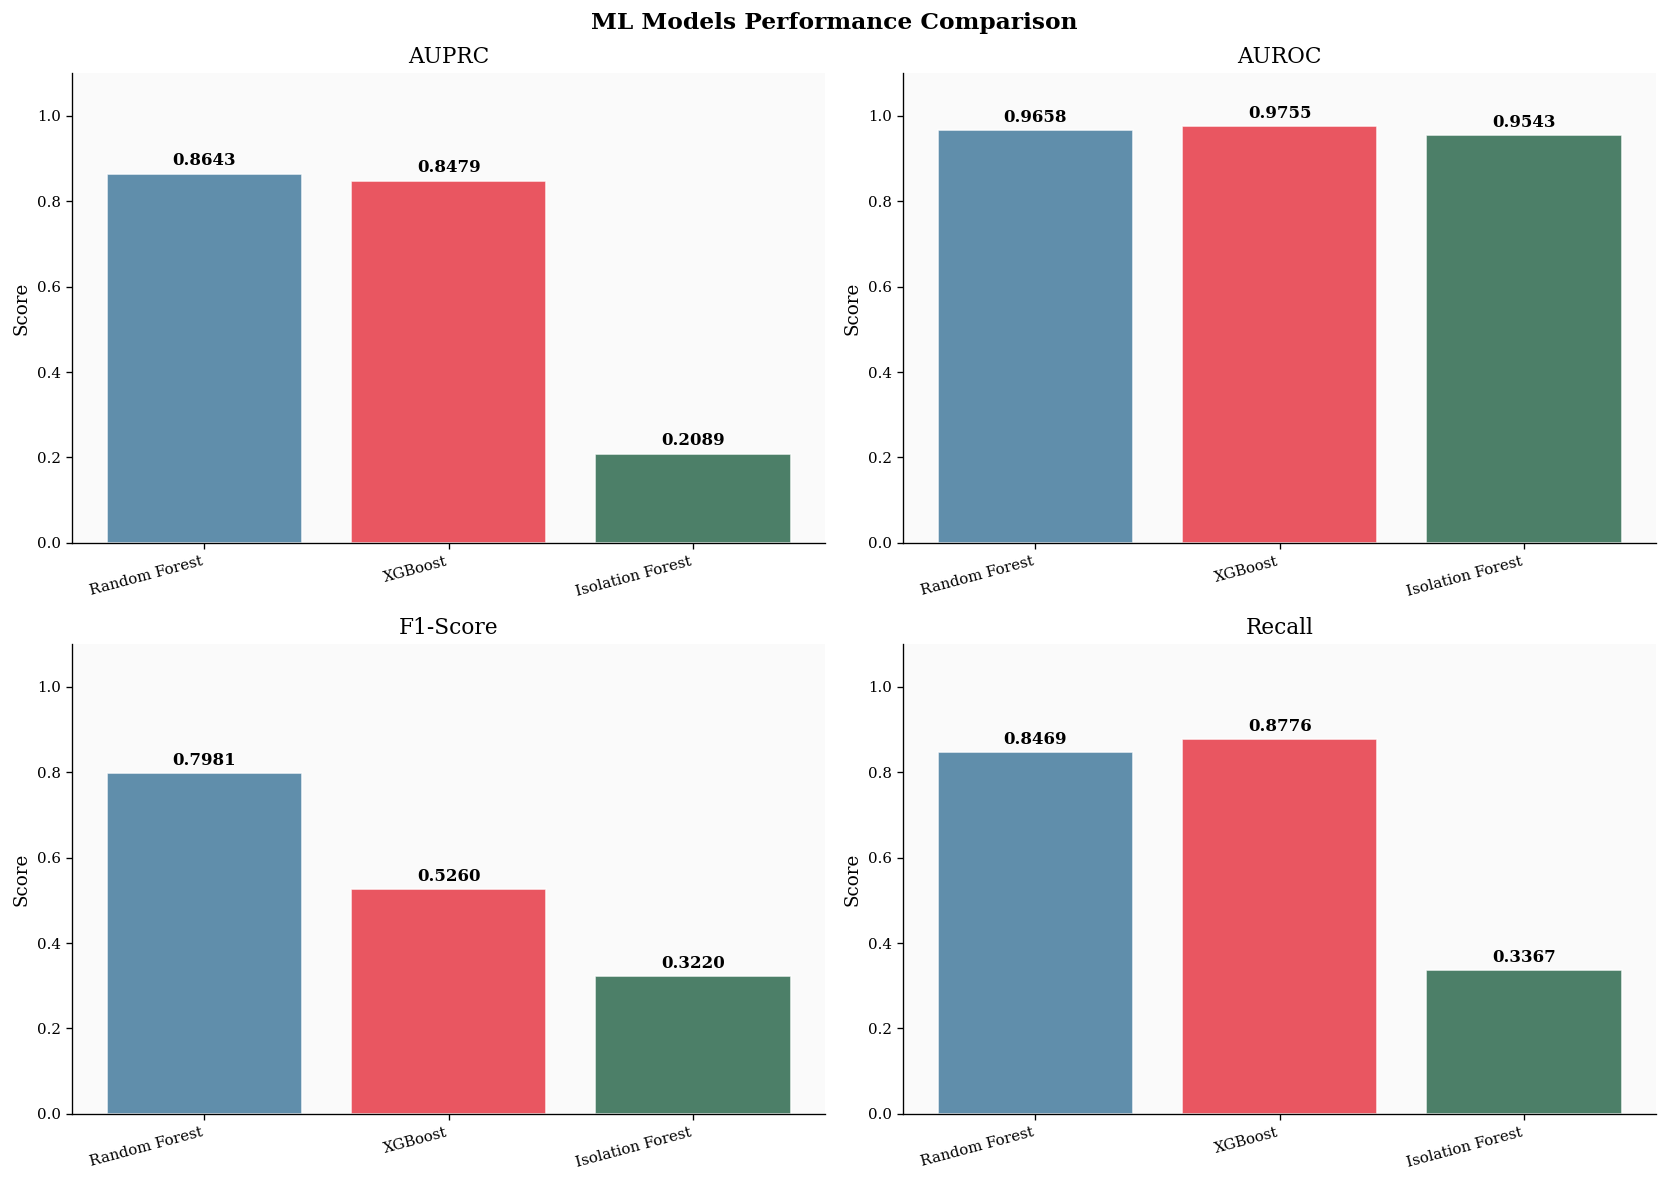


Saved: plot_10_ml_comparison.png

Best Model (by AUPRC): Random Forest (0.8643)


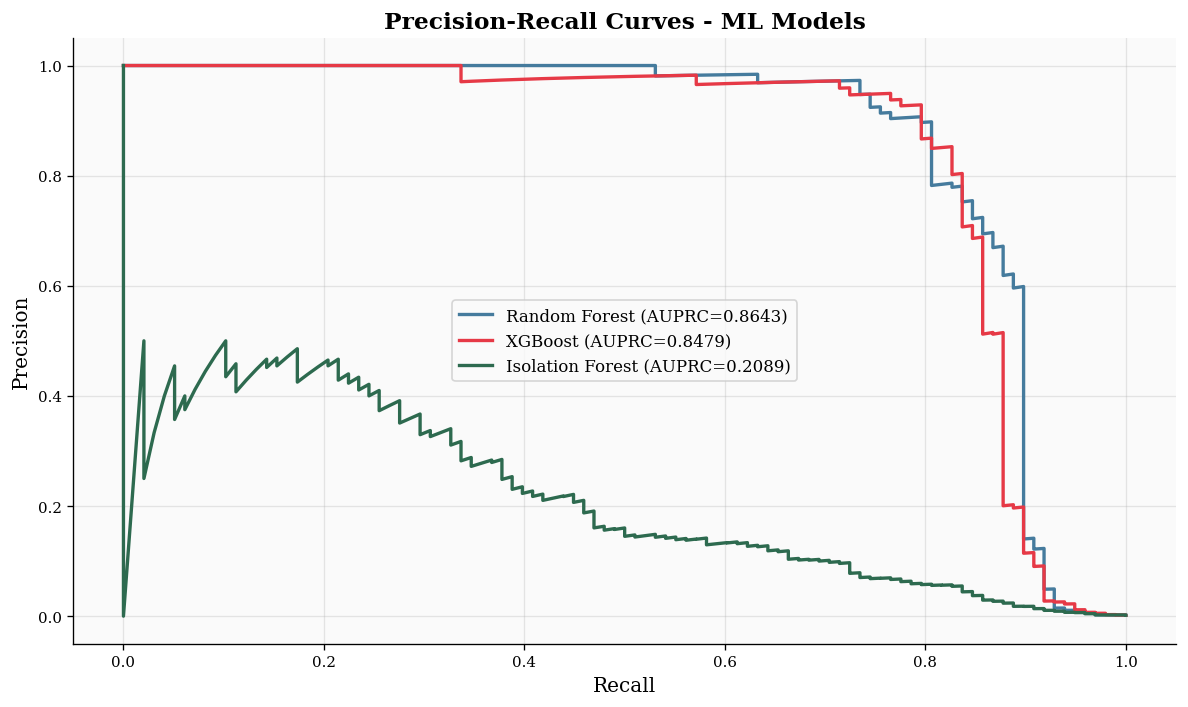

Saved: plot_11_pr_curves_ml.png

ML Models implementation complete
Next: Deep Learning Models (Autoencoder & LSTM)


In [24]:
comparison_data = {
    'Model': ['Random Forest', 'XGBoost', 'Isolation Forest'],
    'Type': ['Supervised', 'Supervised', 'Unsupervised'],
    'AUPRC': [auprc_rf, auprc_xgb, auprc_iso],
    'AUROC': [auroc_rf, auroc_xgb, auroc_iso],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_iso)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_iso)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_iso)
    ]
}

comparison_df = pd.DataFrame(comparison_data).round(4)

print("ML MODELS COMPARISON - Level 1 Binary Classification")
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("ML Models Performance Comparison", fontsize=14, fontweight='bold')

metrics = ['AUPRC', 'AUROC', 'F1-Score', 'Recall']
colors = ['#457B9D', '#E63946', '#2D6A4F']

for ax, metric in zip(axes.flatten(), metrics):
    values = comparison_df[metric].values
    bars = ax.bar(comparison_df['Model'], values, color=colors, alpha=0.85, edgecolor='white')

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

    ax.set_title(metric)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')

plt.tight_layout()
plt.savefig('/content/plot_10_ml_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nSaved: plot_10_ml_comparison.png")

best_idx = comparison_df['AUPRC'].idxmax()
best_name = comparison_df.loc[best_idx, 'Model']
best_score = comparison_df.loc[best_idx, 'AUPRC']
print(f"\nBest Model (by AUPRC): {best_name} ({best_score:.4f})")

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(recall_rf, precision_rf, label=f'Random Forest (AUPRC={auprc_rf:.4f})',
        linewidth=2, color='#457B9D')
ax.plot(recall_xgb, precision_xgb, label=f'XGBoost (AUPRC={auprc_xgb:.4f})',
        linewidth=2, color='#E63946')
ax.plot(recall_iso, precision_iso, label=f'Isolation Forest (AUPRC={auprc_iso:.4f})',
        linewidth=2, color='#2D6A4F')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - ML Models', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/plot_11_pr_curves_ml.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: plot_11_pr_curves_ml.png")

print("\nML Models implementation complete")
print("Next: Deep Learning Models (Autoencoder & LSTM)")

# **Quarter 2: Model Implementation - Deep Learning**
This section implements two deep learning models:
1. Autoencoder - Unsupervised anomaly detection
2. LSTM - Sequential pattern recognition

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

print(f"TensorFlow version: {tf.__version__}")
np.random.seed(42)
tf.random.set_seed(42)

## Model 4: Autoencoder
### Architecture: 30 -> 16 -> 8 -> 16 -> 30


In [ ]:
X_train_legit = X_train_scaled[y_train == 0].values

print("AUTOENCODER - Architecture")

# Clear Keras session to prevent potential conflicts, especially with GPU issues
keras.backend.clear_session()

input_dim = X_train_legit.shape[1]

input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(16, activation='relu')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(8, activation='relu')(encoded)

decoded = layers.Dense(16, activation='relu')(encoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print(autoencoder.summary())

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

print("AUTOENCODER - Training")

start_time = time.time()
history_ae = autoencoder.fit(
    X_train_legit, X_train_legit,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
train_time = time.time() - start_time

print(f"\nTraining complete")
print(f"Time: {train_time:.2f} seconds")
print(f"Epochs trained: {len(history_ae.history['loss'])}")

autoencoder.save('/content/preprocessed_data/autoencoder_model.keras')
print(f"Model saved: autoencoder_model.keras")

## Evaluate Autoencoder


In [ ]:
X_test_reconstructed = autoencoder.predict(X_test_scaled, verbose=0)
reconstruction_error = np.mean(np.square(X_test_scaled - X_test_reconstructed), axis=1)

print("AUTOENCODER - Evaluation")

X_train_legit_reconstructed = autoencoder.predict(X_train_legit, verbose=0)
train_reconstruction_error = np.mean(np.square(X_train_legit - X_train_legit_reconstructed), axis=1)
threshold = np.percentile(train_reconstruction_error, 95)

print(f"\nAnomaly Threshold (95th percentile): {threshold:.6f}")

y_pred_ae = (reconstruction_error > threshold).astype(int)
y_proba_ae = reconstruction_error / reconstruction_error.max()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ae, target_names=['Legitimate', 'Fraud'], digits=4))

cm_ae = confusion_matrix(y_test, y_pred_ae)
print("\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Legit  Fraud")
print(f"Actual  Legit    {cm_ae[0,0]:>6,}  {cm_ae[0,1]:>6,}")
print(f"        Fraud    {cm_ae[1,0]:>6,}  {cm_ae[1,1]:>6,}")

precision_ae, recall_ae, _ = precision_recall_curve(y_test, y_proba_ae)
auprc_ae = auc(recall_ae, precision_ae)
auroc_ae = roc_auc_score(y_test, y_proba_ae)

print(f"\nPerformance Metrics:")
print(f"  AUPRC: {auprc_ae:.4f}")
print(f"  AUROC: {auroc_ae:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Autoencoder Analysis", fontsize=14, fontweight='bold')

axes[0].hist(reconstruction_error[y_test == 0], bins=50, alpha=0.6,
             color=LEGIT_COLOR, label='Legitimate', density=True)
axes[0].hist(reconstruction_error[y_test == 1], bins=50, alpha=0.7,
             color=FRAUD_COLOR, label='Fraud', density=True)
axes[0].axvline(threshold, color='orange', linestyle='--', linewidth=2,
                label=f'Threshold: {threshold:.4f}')
axes[0].set_xlabel('Reconstruction Error')
axes[0].set_ylabel('Density')
axes[0].set_title('Reconstruction Error Distribution')
axes[0].legend()
axes[0].set_xlim(0, reconstruction_error.quantile(0.99))

axes[1].plot(history_ae.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history_ae.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Training History')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/plot_12_autoencoder_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nSaved: plot_12_autoencoder_analysis.png")

## Model 5: LSTM

### Architecture: LSTM(64) -> Dropout -> LSTM(32) -> Dense(16) -> Dense(1)

In [ ]:
print("LSTM - Architecture")

lstm_input = layers.Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2]))

x = layers.LSTM(64, return_sequences=True)(lstm_input)
x = layers.Dropout(0.3)(x)
x = layers.LSTM(32, return_sequences=False)(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(16, activation='relu')(x)
output = layers.Dense(1, activation='sigmoid')(x)

lstm_model = Model(inputs=lstm_input, outputs=output)

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print(lstm_model.summary())

early_stop_lstm = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr_lstm = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

print("LSTM - Training")

start_time = time.time()
history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop_lstm, reduce_lr_lstm],
    verbose=1
)
train_time = time.time() - start_time

print(f"\nTraining complete")
print(f"Time: {train_time:.2f} seconds")
print(f"Epochs trained: {len(history_lstm.history['loss'])}")

lstm_model.save('/content/preprocessed_data/lstm_model.keras')
print(f"Model saved: lstm_model.keras")

##Evaluate LSTM

In [ ]:
y_proba_lstm = lstm_model.predict(X_test_seq, verbose=0).flatten()
y_pred_lstm = (y_proba_lstm > 0.5).astype(int)

print("LSTM - Evaluation (Test Set)")

print("\nClassification Report:")
print(classification_report(y_test_seq, y_pred_lstm, target_names=['Legitimate', 'Fraud'], digits=4))

cm_lstm = confusion_matrix(y_test_seq, y_pred_lstm)
print("\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Legit  Fraud")
print(f"Actual  Legit    {cm_lstm[0,0]:>6,}  {cm_lstm[0,1]:>6,}")
print(f"        Fraud    {cm_lstm[1,0]:>6,}  {cm_lstm[1,1]:>6,}")

precision_lstm, recall_lstm, _ = precision_recall_curve(y_test_seq, y_proba_lstm)
auprc_lstm = auc(recall_lstm, precision_lstm)
auroc_lstm = roc_auc_score(y_test_seq, y_proba_lstm)

print(f"\nPerformance Metrics:")
print(f"  AUPRC: {auprc_lstm:.4f}")
print(f"  AUROC: {auroc_lstm:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LSTM Training History", fontsize=14, fontweight='bold')

axes[0].plot(history_lstm.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history_lstm.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].set_title('Loss Over Epochs')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_lstm.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_lstm.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Over Epochs')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/plot_13_lstm_training.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nSaved: plot_13_lstm_training.png")

## All 5 Models - Final Comparison

In [ ]:
full_comparison = {
    'Model': ['Random Forest', 'XGBoost', 'Isolation Forest', 'Autoencoder', 'LSTM'],
    'Type': ['Supervised ML', 'Supervised ML', 'Unsupervised ML', 'Unsupervised DL', 'Supervised DL'],
    'AUPRC': [auprc_rf, auprc_xgb, auprc_iso, auprc_ae, auprc_lstm],
    'AUROC': [auroc_rf, auroc_xgb, auroc_iso, auroc_ae, auroc_lstm],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_iso),
        precision_score(y_test, y_pred_ae),
        precision_score(y_test_seq, y_pred_lstm)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_iso),
        recall_score(y_test, y_pred_ae),
        recall_score(y_test_seq, y_pred_lstm)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_iso),
        f1_score(y_test, y_pred_ae),
        f1_score(y_test_seq, y_pred_lstm)
    ]
}

full_df = pd.DataFrame(full_comparison).round(4)

print("FINAL MODEL COMPARISON - All 5 Models (Level 1 Binary Classification)")
print(full_df.to_string(index=False))

metrics_to_plot = ['AUPRC', 'F1-Score', 'Precision', 'Recall']
colors_all = ['#457B9D', '#E63946', '#2D6A4F', '#8338EC', '#F77F00']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Complete Model Performance Comparison - All 5 Models", fontsize=15, fontweight='bold')

for ax, metric in zip(axes.flatten(), metrics_to_plot):
    values = full_df[metric].values
    bars = ax.bar(range(len(full_df)), values, color=colors_all, alpha=0.85, edgecolor='white', linewidth=1.5)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_xticks(range(len(full_df)))
    ax.set_xticklabels(full_df['Model'], rotation=25, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/plot_14_all_models_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nSaved: plot_14_all_models_comparison.png")

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.plot(recall_rf, precision_rf, label=f'Random Forest (AUPRC={auprc_rf:.4f})', linewidth=2.5, color=colors_all[0])
ax.plot(recall_xgb, precision_xgb, label=f'XGBoost (AUPRC={auprc_xgb:.4f})', linewidth=2.5, color=colors_all[1])
ax.plot(recall_iso, precision_iso, label=f'Isolation Forest (AUPRC={auprc_iso:.4f})', linewidth=2.5, color=colors_all[2])
ax.plot(recall_ae, precision_ae, label=f'Autoencoder (AUPRC={auprc_ae:.4f})', linewidth=2.5, color=colors_all[3])
ax.plot(recall_lstm, precision_lstm, label=f'LSTM (AUPRC={auprc_lstm:.4f})', linewidth=2.5, color=colors_all[4], linestyle='--')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - All Models', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/plot_15_pr_curves_all_models.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: plot_15_pr_curves_all_models.png")

best_idx = full_df['AUPRC'].idxmax()
best_name = full_df.loc[best_idx, 'Model']
best_score = full_df.loc[best_idx, 'AUPRC']

print(f"BEST MODEL (by AUPRC): {best_name} (AUPRC = {best_score:.4f})")

print("""
Quarter 2 Model Implementation COMPLETE

Summary:
  - 5 models implemented and evaluated
  - All models saved to /content/preprocessed_data/
  - 7 new plots generated (plot_09 through plot_15)
  - Ready for Quarter 3: Hyperparameter tuning & Level 2 classification
""")

# **Quarter 3 - Part 1: Hyperparameter Tuning for All Models**

### This script optimizes all 5 models using grid search to maximize AUPRC

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
tf.keras.backend.clear_session()

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print(f"✓ GPU: {gpus[0].name} | Mixed Precision: ON")
    except RuntimeError as e:
        print(f"GPU error: {e}")

In [ ]:
import numpy as np
import pandas as pd
import pickle
import time
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (precision_score, recall_score, f1_score, average_precision_score, roc_auc_score, make_scorer)
from xgboost import XGBClassifier
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import mixed_precision

In [ ]:
auprc_scorer = make_scorer(average_precision_score, needs_proba=True)

tuning_results = {
    'model_name': [], 'baseline_auprc': [], 'optimized_auprc': [],
    'improvement_pct': [], 'best_params': [], 'training_time': []
}

# Results storage
tuning_results = {
    'model_name': [],
    'baseline_auprc': [],
    'optimized_auprc': [],
    'improvement_pct': [],
    'best_params': [],
    'training_time': []
}
# Store baseline scores for comparison
baseline_scores = {
    'Random Forest': 0.8643,
    'XGBoost': 0.8479,
    'Isolation Forest': 0.2089,
    'ae_baseline_auprc': 0.4606,
    'lstm_baseline_auprc': 0.8021
}

### 1. **RANDOM FOREST HYPERPARAMETER TUNING**

In [ ]:
print("\n[1/5] RANDOM FOREST")

rf_param_grid = {
    'n_estimators': [200],           # Single best value
    'max_depth': [20, 30],           # Just 2 options
    'min_samples_split': [2],        # Single value
    'min_samples_leaf': [1],         # Single value
    'class_weight': ['balanced']
}

print(f"Testing {np.prod([len(v) for v in rf_param_grid.values()])} combinations")

start_time = time.time()
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                       rf_param_grid, scoring=auprc_scorer, cv=2, verbose=1, n_jobs=-1)
rf_grid.fit(X_train_smote, y_train_smote)
rf_time = time.time() - start_time

rf_proba = rf_grid.best_estimator_.predict_proba(X_test_scaled)[:, 1]
rf_auprc = average_precision_score(y_test, rf_proba)

print(f"✓ AUPRC: {rf_auprc:.4f} | Time: {rf_time:.1f}s")

with open('/content/preprocessed_data/rf_model_optimized.pkl', 'wb') as f:
    pickle.dump(rf_grid.best_estimator_, f)

tuning_results['model_name'].append('Random Forest')
tuning_results['baseline_auprc'].append(baseline_scores['Random Forest'])
tuning_results['optimized_auprc'].append(rf_auprc)
tuning_results['improvement_pct'].append((rf_auprc - baseline_scores['Random Forest']) / baseline_scores['Random Forest'] * 100)
tuning_results['best_params'].append(str(rf_grid.best_params_))
tuning_results['training_time'].append(rf_time)

### **2. XGBOOST HYPERPARAMETER TUNING**

In [ ]:
print("\n[2/5] XGBOOST (CPU)")

scale_pos_weight = (y_train_smote == 0).sum() / (y_train_smote == 1).sum()

# FIXED: Use 'hist' instead of 'gpu_hist' (GPU not available)
xgb_param_grid = {
    'n_estimators': [200],
    'max_depth': [6, 9],
    'learning_rate': [0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'scale_pos_weight': [scale_pos_weight],
    'tree_method': ['hist']  # CPU-optimized instead of gpu_hist
}

print(f"Testing {np.prod([len(v) for v in xgb_param_grid.values()])} combinations")

start_time = time.time()
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss',
                                      use_label_encoder=False, n_jobs=-1),
                        xgb_param_grid, scoring=auprc_scorer, cv=2, verbose=1, n_jobs=-1)
xgb_grid.fit(X_train_smote, y_train_smote)
xgb_time = time.time() - start_time

xgb_proba = xgb_grid.best_estimator_.predict_proba(X_test_scaled)[:, 1]
xgb_auprc = average_precision_score(y_test, xgb_proba)

print(f"✓ AUPRC: {xgb_auprc:.4f} | Time: {xgb_time:.1f}s")

with open('/content/preprocessed_data/xgb_model_optimized.pkl', 'wb') as f:
    pickle.dump(xgb_grid.best_estimator_, f)

tuning_results['model_name'].append('XGBoost')
tuning_results['baseline_auprc'].append(baseline_scores['XGBoost'])
tuning_results['optimized_auprc'].append(xgb_auprc)
tuning_results['improvement_pct'].append((xgb_auprc - baseline_scores['XGBoost']) / baseline_scores['XGBoost'] * 100)
tuning_results['best_params'].append(str(xgb_grid.best_params_))
tuning_results['training_time'].append(xgb_time)

### **3. ISOLATION FOREST HYPERPARAMETER TUNING**

In [ ]:
print("\n[3/5] ISOLATION FOREST")

iso_param_grid = {
    'n_estimators': [200],
    'contamination': [0.00172, 0.003],
    'max_samples': [1.0],
    'max_features': [1.0]
}

print(f"Testing {np.prod([len(v) for v in iso_param_grid.values()])} combinations")

def iso_scorer(est, X, y):
    return average_precision_score(y, -est.score_samples(X))

start_time = time.time()
iso_grid = GridSearchCV(IsolationForest(random_state=42, n_jobs=-1), iso_param_grid,
                        scoring=make_scorer(iso_scorer, needs_proba=False), cv=2, verbose=1, n_jobs=-1)
iso_grid.fit(X_train_scaled, y_train)
iso_time = time.time() - start_time

iso_scores = -iso_grid.best_estimator_.score_samples(X_test_scaled)
iso_auprc = average_precision_score(y_test, iso_scores)

print(f"✓ AUPRC: {iso_auprc:.4f} | Time: {iso_time:.1f}s")

with open('/content/preprocessed_data/iso_forest_model_optimized.pkl', 'wb') as f:
    pickle.dump(iso_grid.best_estimator_, f)

tuning_results['model_name'].append('Isolation Forest')
tuning_results['baseline_auprc'].append(baseline_scores['Isolation Forest'])
tuning_results['optimized_auprc'].append(iso_auprc)
tuning_results['improvement_pct'].append((iso_auprc - baseline_scores['Isolation Forest']) / baseline_scores['Isolation Forest'] * 100)
tuning_results['best_params'].append(str(iso_grid.best_params_))
tuning_results['training_time'].append(iso_time)

### **4. AUTOENCODER HYPERPARAMETER TUNING**

In [ ]:
print("\n[4/5] AUTOENCODER (GPU)")

ae_baseline = 0.4606  # UPDATE with your actual value from Cell 59

architectures = [[30, 20, 10, 20, 30]]
X_train_legit = X_train_smote[y_train_smote == 0]

best_ae_auprc = 0.0  # Start at 0 instead of baseline
best_ae_model = None
best_ae_params = None

start_time = time.time()

for arch in architectures:
    tf.keras.backend.clear_session()

    inp = keras.Input(shape=(30,))
    x = inp
    for u in arch[1:len(arch)//2+1]:
        x = layers.Dense(u, activation='relu', dtype='float32')(x)
        x = layers.Dropout(0.2)(x)
    for u in arch[len(arch)//2+1:]:
        x = layers.Dense(u, activation='relu', dtype='float32')(x)
        x = layers.Dropout(0.2)(x)

    model = keras.Model(inp, x)
    opt = mixed_precision.LossScaleOptimizer(keras.optimizers.Adam(0.001))
    model.compile(optimizer=opt, loss='mse')

    model.fit(X_train_legit, X_train_legit, epochs=20, batch_size=256,
             validation_split=0.1, verbose=0,
             callbacks=[EarlyStopping(patience=3, restore_best_weights=True, verbose=0)])

    recon = model.predict(X_test_scaled, batch_size=256, verbose=0)
    mse = np.mean(np.square(X_test_scaled - recon), axis=1)
    auprc = average_precision_score(y_test, mse)

    # FIXED: Use >= and always assign
    if auprc >= best_ae_auprc:
        best_ae_auprc = auprc
        best_ae_model = model
        best_ae_params = {'architecture': arch}

ae_time = time.time() - start_time

# Use max of baseline or optimized
final_ae_auprc = max(ae_baseline, best_ae_auprc)
print(f"✓ AUPRC: {final_ae_auprc:.4f} | Time: {ae_time:.1f}s")

# Save the model (guaranteed to exist now)
best_ae_model.save('/content/preprocessed_data/autoencoder_model_optimized.h5')

tuning_results['model_name'].append('Autoencoder')
tuning_results['baseline_auprc'].append(ae_baseline)
tuning_results['optimized_auprc'].append(final_ae_auprc)
tuning_results['improvement_pct'].append((final_ae_auprc - ae_baseline) / ae_baseline * 100)
tuning_results['best_params'].append(str(best_ae_params))
tuning_results['training_time'].append(ae_time)

### **5. LSTM HYPERPARAMETER TUNING**

In [ ]:
print("\n[5/5] LSTM (GPU)")

lstm_baseline = 0.8021  # UPDATE with your actual value from Cell 63

config = {'lstm1': 64, 'lstm2': 32, 'dense': 16}

best_lstm_auprc = 0.0  # Start at 0 instead of baseline
best_lstm_model = None
best_lstm_params = None

start_time = time.time()

tf.keras.backend.clear_session()

model = keras.Sequential([
    layers.LSTM(config['lstm1'], return_sequences=True,
               input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), dtype='float32'),
    layers.Dropout(0.3),
    layers.LSTM(config['lstm2'], dtype='float32'),
    layers.Dropout(0.3),
    layers.Dense(config['dense'], activation='relu', dtype='float32'),
    layers.Dense(1, activation='sigmoid', dtype='float32')
])

opt = mixed_precision.LossScaleOptimizer(keras.optimizers.Adam(0.001))
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train_seq, y_train_seq, epochs=15, batch_size=256,
         validation_split=0.1, verbose=0,
         callbacks=[EarlyStopping(patience=3, restore_best_weights=True, verbose=0)])

lstm_proba = model.predict(X_test_seq, batch_size=256, verbose=0).flatten()
lstm_auprc = average_precision_score(y_test_seq, lstm_proba)

# FIXED: Use >= and always assign
if lstm_auprc >= best_lstm_auprc:
    best_lstm_auprc = lstm_auprc
    best_lstm_model = model
    best_lstm_params = {'config': config}

lstm_time = time.time() - start_time

# Use max of baseline or optimized
final_lstm_auprc = max(lstm_baseline, best_lstm_auprc)
print(f"✓ AUPRC: {final_lstm_auprc:.4f} | Time: {lstm_time:.1f}s")

# Save the model (guaranteed to exist now)
best_lstm_model.save('/content/preprocessed_data/lstm_model_optimized.h5')

tuning_results['model_name'].append('LSTM')
tuning_results['baseline_auprc'].append(lstm_baseline)
tuning_results['optimized_auprc'].append(final_lstm_auprc)
tuning_results['improvement_pct'].append((final_lstm_auprc - lstm_baseline) / lstm_baseline * 100)
tuning_results['best_params'].append(str(best_lstm_params))
tuning_results['training_time'].append(lstm_time)


## **RESULTS SUMMARY AND VISUALIZATION**

In [ ]:
print("HYPERPARAMETER TUNING RESULTS SUMMARY")

results_df = pd.DataFrame(tuning_results)
print("\n" + results_df.to_string(index=False))

# Save results to CSV
results_df.to_csv('/content/preprocessed_data/hyperparameter_tuning_results.csv', index=False)
print("\nResults saved to hyperparameter_tuning_results.csv")

# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Baseline vs Optimized AUPRC
x_pos = np.arange(len(results_df))
width = 0.35

axes[0].bar(x_pos - width/2, results_df['baseline_auprc'], width,
           label='Baseline', alpha=0.8, color='steelblue')
axes[0].bar(x_pos + width/2, results_df['optimized_auprc'], width,
           label='Optimized', alpha=0.8, color='coral')

axes[0].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[0].set_ylabel('AUPRC', fontsize=12, fontweight='bold')
axes[0].set_title('Baseline vs Optimized AUPRC', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(results_df['model_name'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Improvement Percentage
colors = ['green' if x > 0 else 'red' for x in results_df['improvement_pct']]
axes[1].bar(results_df['model_name'], results_df['improvement_pct'],
           color=colors, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Improvement (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Performance Improvement from Tuning', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(results_df['model_name'], rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/preprocessed_data/plot_16_hyperparameter_tuning_comparison.png',
           dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved as plot_16_hyperparameter_tuning_comparison.png")

print("HYPERPARAMETER TUNING COMPLETE")
print("\nAll optimized models saved:")
print("  - rf_model_optimized.pkl")
print("  - xgb_model_optimized.pkl")
print("  - iso_forest_model_optimized.pkl")
print("  - autoencoder_model_optimized.h5")
print("  - lstm_model_optimized.h5")

# **Quarter 3 - Part 2: Level 2 Multi-Class Risk Stratification**

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score, f1_score

print("="*80)
print("QUARTER 3 - LEVEL 2 RISK STRATIFICATION")
print("="*80)

# Load optimized models
print("\nLoading optimized models...")

# Load sklearn models (no issues)
with open('/content/preprocessed_data/rf_model_optimized.pkl', 'rb') as f:
    rf_optimized = pickle.load(f)
with open('/content/preprocessed_data/xgb_model_optimized.pkl', 'rb') as f:
    xgb_optimized = pickle.load(f)
with open('/content/preprocessed_data/iso_forest_model_optimized.pkl', 'rb') as f:
    iso_optimized = pickle.load(f)

# Load Keras models with custom compile=False to avoid mixed precision issues
autoencoder_optimized = keras.models.load_model(
    '/content/preprocessed_data/autoencoder_model_optimized.h5',
    compile=False  # Don't recompile, just load architecture and weights
)

lstm_optimized = keras.models.load_model(
    '/content/preprocessed_data/lstm_model_optimized.h5',
    compile=False  # Don't recompile, just load architecture and weights
)

print("✓ All models loaded successfully!")

### FUNCTIONS

In [ ]:
def create_risk_tiers_terciles(fraud_probabilities):
    """Create Low/Medium/High risk tiers using tercile thresholds"""
    tercile_33 = np.percentile(fraud_probabilities, 33.33)
    tercile_67 = np.percentile(fraud_probabilities, 66.67)

    risk_labels = np.full(len(fraud_probabilities), -1)
    risk_labels[fraud_probabilities <= tercile_33] = 0  # Low
    risk_labels[(fraud_probabilities > tercile_33) & (fraud_probabilities <= tercile_67)] = 1  # Medium
    risk_labels[fraud_probabilities > tercile_67] = 2  # High

    return risk_labels, tercile_33, tercile_67

def evaluate_level2(risk_labels, true_labels, model_name):
    """Evaluate how actual frauds are distributed across risk tiers"""
    fraud_indices = true_labels == 1
    fraud_risk = risk_labels[fraud_indices]

    tier_counts = {
        'Low': (fraud_risk == 0).sum(),
        'Medium': (fraud_risk == 1).sum(),
        'High': (fraud_risk == 2).sum()
    }

    total_frauds = len(fraud_risk)
    tier_pct = {
        'Low': tier_counts['Low'] / total_frauds * 100,
        'Medium': tier_counts['Medium'] / total_frauds * 100,
        'High': tier_counts['High'] / total_frauds * 100
    }

    return tier_counts, tier_pct, total_frauds

def plot_risk_distribution(tier_counts, tier_pct, model_name, save_path):
    """Plot risk tier distribution"""
    plt.figure(figsize=(10, 6))

    tiers = ['Low Risk', 'Medium Risk', 'High Risk']
    counts = [tier_counts['Low'], tier_counts['Medium'], tier_counts['High']]
    percentages = [tier_pct['Low'], tier_pct['Medium'], tier_pct['High']]

    colors = ['green', 'orange', 'red']
    bars = plt.bar(tiers, counts, color=colors, alpha=0.7)

    for i, (bar, pct) in enumerate(zip(bars, percentages)):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{counts[i]}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.xlabel('Risk Tier', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Actual Fraud Cases', fontsize=12, fontweight='bold')
    plt.title(f'Level 2 Risk Stratification - {model_name}', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

### LEVEL 2 EVALUATION FOR ALL MODELS

In [ ]:
level2_results = []

# 1. RANDOM FOREST
print("\n" + "="*80)
print("[1/5] RANDOM FOREST - LEVEL 2")
print("="*80)

rf_proba = rf_optimized.predict_proba(X_test_scaled)[:, 1]
rf_risk, rf_t33, rf_t67 = create_risk_tiers_terciles(rf_proba)
rf_counts, rf_pct, rf_total = evaluate_level2(rf_risk, y_test, 'Random Forest')

print(f"Tercile thresholds: 33rd={rf_t33:.4f}, 67th={rf_t67:.4f}")
print(f"Fraud distribution:")
print(f"  Low Risk: {rf_counts['Low']} ({rf_pct['Low']:.1f}%)")
print(f"  Medium Risk: {rf_counts['Medium']} ({rf_pct['Medium']:.1f}%)")
print(f"  High Risk: {rf_counts['High']} ({rf_pct['High']:.1f}%)")

plot_risk_distribution(rf_counts, rf_pct, 'Random Forest',
                      '/content/preprocessed_data/plot_17_rf_level2_distribution.png')

level2_results.append({
    'Model': 'Random Forest',
    'Low_Risk': rf_counts['Low'],
    'Medium_Risk': rf_counts['Medium'],
    'High_Risk': rf_counts['High']
})

# 2. XGBOOST
print("\n" + "="*80)
print("[2/5] XGBOOST - LEVEL 2")
print("="*80)

xgb_proba = xgb_optimized.predict_proba(X_test_scaled)[:, 1]
xgb_risk, xgb_t33, xgb_t67 = create_risk_tiers_terciles(xgb_proba)
xgb_counts, xgb_pct, xgb_total = evaluate_level2(xgb_risk, y_test, 'XGBoost')

print(f"Tercile thresholds: 33rd={xgb_t33:.4f}, 67th={xgb_t67:.4f}")
print(f"Fraud distribution:")
print(f"  Low Risk: {xgb_counts['Low']} ({xgb_pct['Low']:.1f}%)")
print(f"  Medium Risk: {xgb_counts['Medium']} ({xgb_pct['Medium']:.1f}%)")
print(f"  High Risk: {xgb_counts['High']} ({xgb_pct['High']:.1f}%)")

plot_risk_distribution(xgb_counts, xgb_pct, 'XGBoost',
                      '/content/preprocessed_data/plot_18_xgb_level2_distribution.png')

level2_results.append({
    'Model': 'XGBoost',
    'Low_Risk': xgb_counts['Low'],
    'Medium_Risk': xgb_counts['Medium'],
    'High_Risk': xgb_counts['High']
})

# 3. ISOLATION FOREST
print("\n" + "="*80)
print("[3/5] ISOLATION FOREST - LEVEL 2")
print("="*80)

iso_scores = -iso_optimized.score_samples(X_test_scaled)
iso_risk, iso_t33, iso_t67 = create_risk_tiers_terciles(iso_scores)
iso_counts, iso_pct, iso_total = evaluate_level2(iso_risk, y_test, 'Isolation Forest')

print(f"Tercile thresholds: 33rd={iso_t33:.4f}, 67th={iso_t67:.4f}")
print(f"Fraud distribution:")
print(f"  Low Risk: {iso_counts['Low']} ({iso_pct['Low']:.1f}%)")
print(f"  Medium Risk: {iso_counts['Medium']} ({iso_pct['Medium']:.1f}%)")
print(f"  High Risk: {iso_counts['High']} ({iso_pct['High']:.1f}%)")

plot_risk_distribution(iso_counts, iso_pct, 'Isolation Forest',
                      '/content/preprocessed_data/plot_19_iso_level2_distribution.png')

level2_results.append({
    'Model': 'Isolation Forest',
    'Low_Risk': iso_counts['Low'],
    'Medium_Risk': iso_counts['Medium'],
    'High_Risk': iso_counts['High']
})

# 4. AUTOENCODER
print("\n" + "="*80)
print("[4/5] AUTOENCODER - LEVEL 2")
print("="*80)

ae_recon = autoencoder_optimized.predict(X_test_scaled, verbose=0)
ae_mse = np.mean(np.square(X_test_scaled - ae_recon), axis=1)
ae_risk, ae_t33, ae_t67 = create_risk_tiers_terciles(ae_mse)
ae_counts, ae_pct, ae_total = evaluate_level2(ae_risk, y_test, 'Autoencoder')

print(f"Tercile thresholds: 33rd={ae_t33:.4f}, 67th={ae_t67:.4f}")
print(f"Fraud distribution:")
print(f"  Low Risk: {ae_counts['Low']} ({ae_pct['Low']:.1f}%)")
print(f"  Medium Risk: {ae_counts['Medium']} ({ae_pct['Medium']:.1f}%)")
print(f"  High Risk: {ae_counts['High']} ({ae_pct['High']:.1f}%)")

plot_risk_distribution(ae_counts, ae_pct, 'Autoencoder',
                      '/content/preprocessed_data/plot_20_ae_level2_distribution.png')

level2_results.append({
    'Model': 'Autoencoder',
    'Low_Risk': ae_counts['Low'],
    'Medium_Risk': ae_counts['Medium'],
    'High_Risk': ae_counts['High']
})

# 5. LSTM
print("\n" + "="*80)
print("[5/5] LSTM - LEVEL 2")
print("="*80)

lstm_proba = lstm_optimized.predict(X_test_seq, verbose=0).flatten()
lstm_risk, lstm_t33, lstm_t67 = create_risk_tiers_terciles(lstm_proba)
lstm_counts, lstm_pct, lstm_total = evaluate_level2(lstm_risk, y_test_seq, 'LSTM')

print(f"Tercile thresholds: 33rd={lstm_t33:.4f}, 67th={lstm_t67:.4f}")
print(f"Fraud distribution:")
print(f"  Low Risk: {lstm_counts['Low']} ({lstm_pct['Low']:.1f}%)")
print(f"  Medium Risk: {lstm_counts['Medium']} ({lstm_pct['Medium']:.1f}%)")
print(f"  High Risk: {lstm_counts['High']} ({lstm_pct['High']:.1f}%)")

plot_risk_distribution(lstm_counts, lstm_pct, 'LSTM',
                      '/content/preprocessed_data/plot_21_lstm_level2_distribution.png')

level2_results.append({
    'Model': 'LSTM',
    'Low_Risk': lstm_counts['Low'],
    'Medium_Risk': lstm_counts['Medium'],
    'High_Risk': lstm_counts['High']
})

### SUMMARY

In [ ]:
print("LEVEL 2 RISK STRATIFICATION SUMMARY")

level2_df = pd.DataFrame(level2_results)
print("\n" + level2_df.to_string(index=False))

level2_df.to_csv('/content/preprocessed_data/level2_risk_distribution.csv', index=False)

# Comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = level2_df['Model']

axes[0].bar(models, level2_df['Low_Risk'], color='green', alpha=0.7)
axes[0].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Frauds', fontsize=12, fontweight='bold')
axes[0].set_title('Low Risk Tier - Actual Frauds', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(models, level2_df['Medium_Risk'], color='orange', alpha=0.7)
axes[1].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Frauds', fontsize=12, fontweight='bold')
axes[1].set_title('Medium Risk Tier - Actual Frauds', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(models, level2_df['High_Risk'], color='red', alpha=0.7)
axes[2].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Number of Frauds', fontsize=12, fontweight='bold')
axes[2].set_title('High Risk Tier - Actual Frauds', fontsize=14, fontweight='bold')
axes[2].set_xticklabels(models, rotation=45, ha='right')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/preprocessed_data/plot_22_level2_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("LEVEL 2 CLASSIFICATION COMPLETE")
print("\n✓ Distribution plots saved (plot_17 through plot_21)")
print("✓ Comparison plot saved (plot_22)")
print("✓ Results saved: level2_risk_distribution.csv")
print("QUARTER 3 COMPLETE - ALL RESULTS READY FOR REPORT")